# Ingesta, Preprocesamiento, EDA y Baseline

El mapeo tradicional de zonas de interés aurífero mediante **isovalores de Au** es univariable: solo delimita zonas donde el Au medido es alto, produciendo áreas pequeñas y **omitiendo "zonas ciegas"** — lugares donde el Au superficial es bajo pero cuya **firma geoquímica multi-elemento** (pathfinders y alteración) se parece a la de las zonas mineralizadas.

Este proyecto propone un **clasificador de Machine Learning multivariable** que aprende la firma del **halo geoquímico** (pathfinders + alteración hidrotermal) para identificar zonas de interés que el mapeo de isovalores dejaría fuera, y así **dirigir trabajos de muestreo** hacia zonas ciegas. Se trabaja con **datos históricos**: el modelo debe exprimir al máximo la información disponible.

**Decisión de diseño central:** los **elementos económicos (Au, Ag, Cu, Pb, Zn) se excluyen del set de features**. Si un elemento económico está presente en concentraciones anómalas, la zona ya se sabe mineralizada — usarlo como predictor equivale a detectar el cuerpo mineralizado, no el halo. El modelo debe predecir a partir de la señal **indirecta** (pathfinders, alteración, litología), que es la única disponible en una zona ciega real.

## Configuración

In [1]:
import warnings, os, json, platform
from datetime import datetime
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.spatial import cKDTree

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.metrics import (f1_score, fbeta_score, make_scorer, accuracy_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

OUT = 'outputs_sprint0'
DIR_DATA, DIR_MODELS, DIR_FIG, DIR_TAB = f'{OUT}/data', f'{OUT}/models', f'{OUT}/figures', f'{OUT}/tables'
for d in (OUT, DIR_DATA, DIR_MODELS, DIR_FIG, DIR_TAB):
    os.makedirs(d, exist_ok=True)

MODEL_COLORS = {
    'KNN': 'blue', 'Reg. Logística': 'orange', 'SVM (RBF)': 'teal', 'MLP': 'magenta',
    'Árbol de Decisión': 'green', 'Random Forest': 'darkred', 'ExtraTrees': 'olive',
    'HistGradientBoosting': 'brown', 'XGBoost': 'purple', 'LightGBM': 'darkcyan', 'CatBoost': 'goldenrod',
}
MODELOS = list(MODEL_COLORS.keys())

# ── Estilo de impresión ──
def coral(texto):
    '''Resalta texto en color coral para resultados clave.'''
    return f'\033[38;2;255;127;80m{texto}\033[0m'

print('Carpetas listas:', OUT)

Carpetas listas: outputs_sprint0


## Versiones de librerías

In [2]:
import sklearn, imblearn, catboost
versiones = {
    'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__, 'imbalanced-learn': imblearn.__version__,
    'xgboost': xgb.__version__, 'lightgbm': lgb.__version__, 'catboost': catboost.__version__,
    'matplotlib': __import__('matplotlib').__version__, 'seaborn': sns.__version__, 'joblib': joblib.__version__,
}
with open(f'{OUT}/versiones_librerias.json', 'w') as f:
    json.dump(versiones, f, indent=2, ensure_ascii=False)
print('Versiones registradas:')
for k, v in versiones.items():
    print(f'  {k:18s}: {v}')

Versiones registradas:
  python            : 3.12.1
  numpy             : 2.4.6
  pandas            : 2.3.3
  scikit-learn      : 1.9.0
  imbalanced-learn  : 0.14.2
  xgboost           : 3.3.0
  lightgbm          : 4.6.0
  catboost          : 1.2.10
  matplotlib        : 3.11.0
  seaborn           : 0.13.2
  joblib            : 1.5.3


## Ingesta

In [3]:
RUTA_RAW = '../data/raw/DataSet.csv'
df_raw = pd.read_csv(RUTA_RAW)
print(f'Dataset crudo: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')

Dataset crudo: 2132 filas × 52 columnas


## Preprocesamiento

**Valores censurados:** `<L → L/2`, `>L → L·1.1` (Hornung & Reed 1990; Helsel 2005 — sustitución por límite de detección, estándar en geoquímica).

**Variable objetivo:** `target_Au = 1` si `Au_ppm > 0.10`, umbral fijado por el stakeholder.

**Indicadores de detección:** para elementos con censura intermedia (30–90%), la censura misma es informativa ("detectado vs no detectado" ya discrimina halo de fondo). Se conserva el valor sustituido L/2 **y** se crea un indicador binario de detección (p. ej. `Te_detectado`).

In [4]:
def parse_censurado(v):
    '''Sustitución de valores censurados.'''
    if isinstance(v, str):
        v = v.strip()
        if v.startswith('<'):
            try: return float(v[1:]) / 2
            except: return np.nan
        if v.startswith('>'):
            try: return float(v[1:]) * 1.1
            except: return np.nan
    try: return float(v)
    except: return np.nan

df = df_raw.copy()
COLS_FUERA = ['Codigo', 'Datum', 'Zone', 'Unnamed: 4']
df = df.drop(columns=[c for c in COLS_FUERA if c in df.columns], errors='ignore')

COORDS = ['East', 'North', 'Level']

# ── Fracción de censura por elemento (ANTES de sustituir) ──
frac_cens, mask_lt = {}, {}
n_cens = 0
for col in df.columns:
    if col in COORDS: continue
    if df[col].dtype == object:
        s = df[col].astype(str).str.strip()
        m = s.str.startswith('<')
        mask_lt[col] = m
        frac_cens[col] = float(m.mean())
        n_cens += s.str.startswith(('<', '>')).sum()
    else:
        frac_cens[col] = 0.0
    df[col] = df[col].apply(parse_censurado)

UMBRAL_AU = 0.10
df['target_Au'] = (df['Au_ppm'] > UMBRAL_AU).astype(int)

print(f'Valores censurados sustituidos: {int(n_cens)}')
print(f'Columnas eliminadas: {[c for c in COLS_FUERA if c in df_raw.columns]}')
print(f'Variable objetivo creada (Au > {UMBRAL_AU} ppm)')
print(f'  target_Au: {df["target_Au"].value_counts().to_dict()}')
print(f'Shape: {df.shape}')

Valores censurados sustituidos: 8231
Columnas eliminadas: ['Codigo', 'Unnamed: 4']
Variable objetivo creada (Au > 0.1 ppm)
  target_Au: {0: 1872, 1: 260}
Shape: (2132, 51)


## Exclusión de elementos económicos

El objetivo de la tesis es detectar **zonas ciegas** para muestreo dirigido: donde hay elementos económicos anómalos, la mineralización ya es conocida. Usar Ag (o Cu, Pb, Zn) como predictor es equivalente a usar el propio Au — delata la mineralización en vez de predecirla a partir del halo.

- **Se excluyen:** `Au_ppm` (solo variable objetivo), `Ag_ppm`, `Cu_ppm`, `Pb_ppm`, `Zn_ppm`.
- **Mo se mantiene como pathfinder:** en sistemas epitermales actúa como pathfinder distal de la suite magmático-hidrotermal (junto a As, Sb, Te, Bi) y no constituye objetivo económico en el contexto del yacimiento estudiado. Su contribución se someterá a la ablación del Sprint 3.
- **Verificación de sustitutos encubiertos:** Cd y Ge se alojan casi exclusivamente en la esfalerita (mena de Zn). Si su correlación con Zn es muy alta, el modelo podría usarlos como "Zn disfrazado" — se verifica con los datos y se excluyen con evidencia si corresponde.

In [5]:
ECONOMICOS = ['Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm']

# ── Verificación de sustitutos encubiertos de Zn (Cd y Ge viven en la esfalerita) ──
UMBRAL_SUSTITUTO = 0.90
print('── Verificación Cd/Ge como sustitutos de Zn ──')
for elem in ['Cd_ppm', 'Ge_ppm']:
    rho = df[elem].corr(df['Zn_ppm'], method='spearman')
    if abs(rho) > UMBRAL_SUSTITUTO:
        ECONOMICOS.append(elem)
        print(coral(f'  {elem}: corr Spearman con Zn = {rho:.3f} > {UMBRAL_SUSTITUTO} → EXCLUIDO ("Zn disfrazado")'))
    else:
        print(f'  {elem}: corr Spearman con Zn = {rho:.3f} ≤ {UMBRAL_SUSTITUTO} → se mantiene como pathfinder')

print(f'\nElementos económicos excluidos del set de features: {ECONOMICOS}')
print('Au_ppm se conserva en el dataset SOLO como origen del target (nunca como feature).')

── Verificación Cd/Ge como sustitutos de Zn ──
  Cd_ppm: corr Spearman con Zn = 0.629 ≤ 0.9 → se mantiene como pathfinder
  Ge_ppm: corr Spearman con Zn = 0.399 ≤ 0.9 → se mantiene como pathfinder

Elementos económicos excluidos del set de features: ['Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm']
Au_ppm se conserva en el dataset SOLO como origen del target (nunca como feature).


## Exclusión por censura e indicadores de detección

- **Censura > 90%:** el elemento casi no tiene información medida → se elimina.
- **Censura 30–90%:** se conserva el valor L/2 **+ indicador binario de detección** (la censura es informativa).
- **Censura < 30%:** sustitución L/2 simple.

In [6]:
tabla_cens = pd.Series(frac_cens, name='frac_censurado').drop(
    ['Au_ppm'] + [c for c in ECONOMICOS if c in frac_cens], errors='ignore').sort_values(ascending=False)
tabla_cens.round(3).to_csv(f'{DIR_TAB}/censura_por_elemento.csv')
print(f'Guardada en {DIR_TAB}/censura_por_elemento.csv')
display(tabla_cens.head(10).round(3).to_frame())

UMBRAL_ELIMINAR, UMBRAL_INDICADOR = 0.90, 0.30
CENSURA_ALTA = [c for c in tabla_cens.index if tabla_cens[c] > UMBRAL_ELIMINAR]
CENSURA_MEDIA = [c for c in tabla_cens.index if UMBRAL_INDICADOR <= tabla_cens[c] <= UMBRAL_ELIMINAR]

print(f'Censura > {UMBRAL_ELIMINAR:.0%} → eliminados: {CENSURA_ALTA}')
print(f'Censura {UMBRAL_INDICADOR:.0%}–{UMBRAL_ELIMINAR:.0%} → indicador de detección: {CENSURA_MEDIA}')

INDICADORES = []
for col in CENSURA_MEDIA:
    nombre = col.split('_')[0] + '_detectado'
    df[nombre] = (~mask_lt[col]).astype(int) if col in mask_lt else 1
    INDICADORES.append(nombre)
    print(f'  {nombre}: detectados = {int(df[nombre].sum())} / {len(df)} ({df[nombre].mean()*100:.1f}%)')

EXCLUIDOS_TOTAL = ECONOMICOS + CENSURA_ALTA
df = df.drop(columns=[c for c in EXCLUIDOS_TOTAL if c in df.columns])
print(f'\nColumnas excluidas: {EXCLUIDOS_TOTAL}')
print(f'Shape final: {df.shape}')

RUTA_PROC = f'{DIR_DATA}/data_procesada.csv'
df.to_csv(RUTA_PROC, index=False)
print(f'Guardado en {RUTA_PROC}')

Guardada en outputs_sprint0/tables/censura_por_elemento.csv


,frac_censurado
Re_ppm,0.947
Se_ppm,0.818
Te_ppm,0.682
Ge_ppm,0.280
S_per,0.227
Ta_ppm,0.118
Bi_ppm,0.074
Cd_ppm,0.043
Hf_ppm,0.035
Sn_ppm,0.029


Censura > 90% → eliminados: ['Re_ppm']
Censura 30%–90% → indicador de detección: ['Se_ppm', 'Te_ppm']
  Se_detectado: detectados = 388 / 2132 (18.2%)
  Te_detectado: detectados = 679 / 2132 (31.8%)

Columnas excluidas: ['Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm', 'Re_ppm']
Shape final: (2132, 48)
Guardado en outputs_sprint0/data/data_procesada.csv


## Análisis Exploratorio de Datos (EDA)

### Clasificación geoquímica de los features

Los elementos se organizan en **cuatro grupos con sustento geoquímico**, según su comportamiento frente al fluido hidrotermal. Cada grupo responde una pregunta distinta:

| Grupo | Elementos | Pregunta que responde |
|---|---|---|
| **Mayores** | Al, Fe, Mg, Ca, Na, K, Ti, P, S, Mn | ¿Cuán alterada está la roca? (la alteración lixivia Na/Ca y enriquece K; S = sulfuros; Mn = carbonatos hidrotermales) |
| **Trazas inmóviles** | Zr, Nb, Y, Th, Hf, Ta, Sc, Ga, La, Ce, V, Cr, Ni, Co, U | ¿Qué roca es? (no las mueve el fluido → preservan la firma litológica original incluso en roca alterada; Winchester & Floyd 1977) |
| **Trazas móviles (pathfinders)** | As, Sb, Tl, Te, Se, Bi, Ge, Mo, W, Sn, Cd | ¿Qué tan cerca del sistema mineralizante? (forman el halo de dispersión; White & Hedenquist 1995) |
| **LILE / álcalis móviles** | Rb, Cs, Sr, Ba, Be | Alteración complementaria (Rb sube con sericita; Sr baja con destrucción de plagioclasa) |

Más los **indicadores de detección** creados en el preprocesamiento. *Limitación: el dataset no incluye Hg, pathfinder distal epitermal clásico.*

In [8]:
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']

GRUPOS = {
    'Mayores (alteración)': ['Al_per', 'Fe_per', 'Mg_per', 'Ca_per', 'Na_per',
                             'K_per', 'Ti_per', 'P_ppm', 'S_per', 'Mn_ppm'],
    'Trazas inmóviles (litología)': ['Zr_ppm', 'Nb_ppm', 'Y_ppm', 'Th_ppm', 'Hf_ppm', 'Ta_ppm', 'Sc_ppm',
                                     'Ga_ppm', 'La_ppm', 'Ce_ppm', 'V_ppm', 'Cr_ppm', 'Ni_ppm', 'Co_ppm', 'U_ppm'],
    'Trazas móviles (pathfinders)': ['As_ppm', 'Sb_ppm', 'Tl_ppm', 'Te_ppm', 'Se_ppm', 'Bi_ppm',
                                     'Ge_ppm', 'Mo_ppm', 'W_ppm', 'Sn_ppm', 'Cd_ppm'],
    'LILE/álcalis (alteración compl.)': ['Rb_ppm', 'Cs_ppm', 'Sr_ppm', 'Ba_ppm', 'Be_ppm'],
    'Indicadores de detección': INDICADORES,
}
GRUPOS = {g: [c for c in cols if c in df.columns] for g, cols in GRUPOS.items()}
FEATURES = [c for cols in GRUPOS.values() for c in cols]

sin_grupo = [c for c in df.columns if c not in FEATURES and c not in EXCLUIR]
assert not sin_grupo, f'Elementos sin grupo asignado: {sin_grupo}'

y_full = df['target_Au'].astype(int)

print(f'N.º muestras: {df.shape[0]} | Features: {len(FEATURES)}')
for g, cols in GRUPOS.items():
    print(f'  {g}: {len(cols)} → {cols}')
print(f'Coordenadas: {COORDS}')

N.º muestras: 2132 | Features: 43
  Mayores (alteración): 10 → ['Al_per', 'Fe_per', 'Mg_per', 'Ca_per', 'Na_per', 'K_per', 'Ti_per', 'P_ppm', 'S_per', 'Mn_ppm']
  Trazas inmóviles (litología): 15 → ['Zr_ppm', 'Nb_ppm', 'Y_ppm', 'Th_ppm', 'Hf_ppm', 'Ta_ppm', 'Sc_ppm', 'Ga_ppm', 'La_ppm', 'Ce_ppm', 'V_ppm', 'Cr_ppm', 'Ni_ppm', 'Co_ppm', 'U_ppm']
  Trazas móviles (pathfinders): 11 → ['As_ppm', 'Sb_ppm', 'Tl_ppm', 'Te_ppm', 'Se_ppm', 'Bi_ppm', 'Ge_ppm', 'Mo_ppm', 'W_ppm', 'Sn_ppm', 'Cd_ppm']
  LILE/álcalis (alteración compl.): 5 → ['Rb_ppm', 'Cs_ppm', 'Sr_ppm', 'Ba_ppm', 'Be_ppm']
  Indicadores de detección: 2 → ['Se_detectado', 'Te_detectado']
Coordenadas: ['East', 'North', 'Level']


### Desbalance de clases

════════════ DESBALANCE ════════════
Negativos:  1872  (87.80%)
Positivos:   260  (12.20%)
Prevalencia positiva: 0.1220
Razón de desbalance (IR): 7.20:1

Accuracy engañoso: clasificador trivial "todo negativo" = 87.80%
Métrica principal: Recall (clase positiva); secundaria: AUC-PR; escalar de decisión: F2


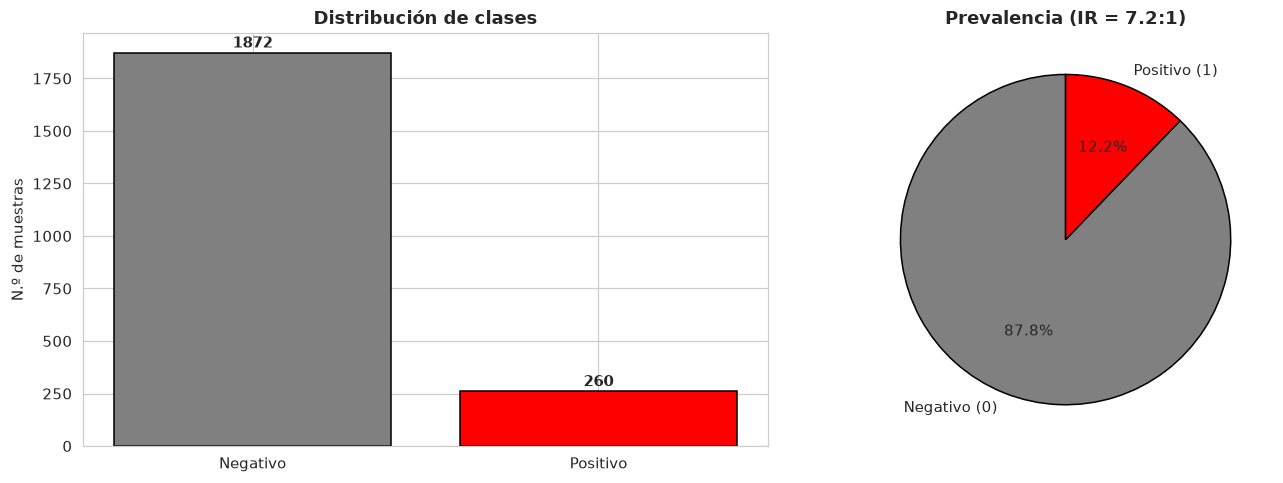

In [9]:
n_neg = int((y_full == 0).sum()); n_pos = int((y_full == 1).sum())
prevalencia = n_pos / (n_pos + n_neg); razon_desb = n_neg / max(n_pos, 1)

print('════════════ DESBALANCE ════════════')
print(f'Negativos: {n_neg:5d}  ({(1-prevalencia)*100:5.2f}%)')
print(f'Positivos: {n_pos:5d}  ({prevalencia*100:5.2f}%)')
print(f'Prevalencia positiva: {prevalencia:.4f}')
print(f'Razón de desbalance (IR): {razon_desb:.2f}:1')
print(f'\nAccuracy engañoso: clasificador trivial "todo negativo" = {(1-prevalencia)*100:.2f}%')
print('Métrica principal: Recall (clase positiva); secundaria: AUC-PR; escalar de decisión: F2')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
b = axes[0].bar(['Negativo', 'Positivo'], [n_neg, n_pos], color=['gray', 'red'], edgecolor='black')
for r in b:
    axes[0].text(r.get_x()+r.get_width()/2, r.get_height()+8, f'{int(r.get_height())}',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribución de clases', fontweight='bold')
axes[0].set_ylabel('N.º de muestras')
axes[1].pie([n_neg, n_pos], labels=['Negativo (0)', 'Positivo (1)'], autopct='%1.1f%%',
            colors=['gray', 'red'], startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title(f'Prevalencia (IR = {razon_desb:.1f}:1)', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/eda_desbalance.png', bbox_inches='tight'); plt.show()

### Estadística descriptiva

In [10]:
desc_global = df[FEATURES].describe().T
desc_global['skew'] = df[FEATURES].skew()
desc_global['n_nulos'] = df[FEATURES].isna().sum()
desc_global = desc_global.round(3)
desc_global.to_csv(f'{DIR_TAB}/eda_descriptivos_global.csv')
print(f'Guardada en {DIR_TAB}/eda_descriptivos_global.csv')
display(desc_global)

Guardada en outputs_sprint0/tables/eda_descriptivos_global.csv


,count,mean,std,min,25%,50%,75%,max,skew,n_nulos
Al_per,2132.0,5.144,3.026,0.050,2.318,5.515,7.870,15.850,-0.002,0
Fe_per,2132.0,3.377,3.410,0.180,1.450,2.655,4.602,55.000,6.710,0
Mg_per,2132.0,0.782,0.905,0.005,0.160,0.480,1.220,10.350,3.560,0
Ca_per,2132.0,2.669,4.558,0.005,0.130,1.260,3.350,35.070,3.918,0
Na_per,2132.0,0.907,1.087,0.005,0.030,0.250,1.870,5.090,0.944,0
K_per,2132.0,1.395,1.045,0.005,0.550,1.225,2.030,8.390,1.042,0
Ti_per,2132.0,0.237,0.182,0.002,0.080,0.190,0.400,0.960,0.588,0
P_ppm,2132.0,467.980,370.589,9.380,157.735,383.060,748.355,4268.940,1.753,0
S_per,2132.0,0.201,0.840,0.005,0.010,0.020,0.080,11.000,9.360,0
Mn_ppm,2132.0,844.452,1559.598,19.870,284.295,623.275,971.062,41050.260,13.186,0


In [11]:
df_neg = df[df['target_Au'] == 0][FEATURES]
df_pos = df[df['target_Au'] == 1][FEATURES]
comp = pd.DataFrame({
    'media_neg': df_neg.mean(), 'mediana_neg': df_neg.median(),
    'media_pos': df_pos.mean(), 'mediana_pos': df_pos.median(),
}).round(3)
comp['ratio_media'] = (comp['media_pos'] / comp['media_neg'].replace(0, np.nan)).round(2)
comp.to_csv(f'{DIR_TAB}/eda_comparativa_clase.csv')
print(f'Guardada en {DIR_TAB}/eda_comparativa_clase.csv')
display(comp)

Guardada en outputs_sprint0/tables/eda_comparativa_clase.csv


,media_neg,mediana_neg,media_pos,mediana_pos,ratio_media
Al_per,5.457,6.140,2.889,2.320,0.53
Fe_per,3.353,2.800,3.550,1.780,1.06
Mg_per,0.849,0.550,0.297,0.175,0.35
Ca_per,2.793,1.500,1.777,0.145,0.64
Na_per,1.014,0.390,0.137,0.030,0.14
K_per,1.449,1.285,1.008,0.660,0.70
Ti_per,0.254,0.210,0.118,0.080,0.46
P_ppm,496.922,429.280,259.595,190.805,0.52
S_per,0.160,0.020,0.493,0.030,3.08
Mn_ppm,873.344,663.020,636.430,253.680,0.73


### Histogramas

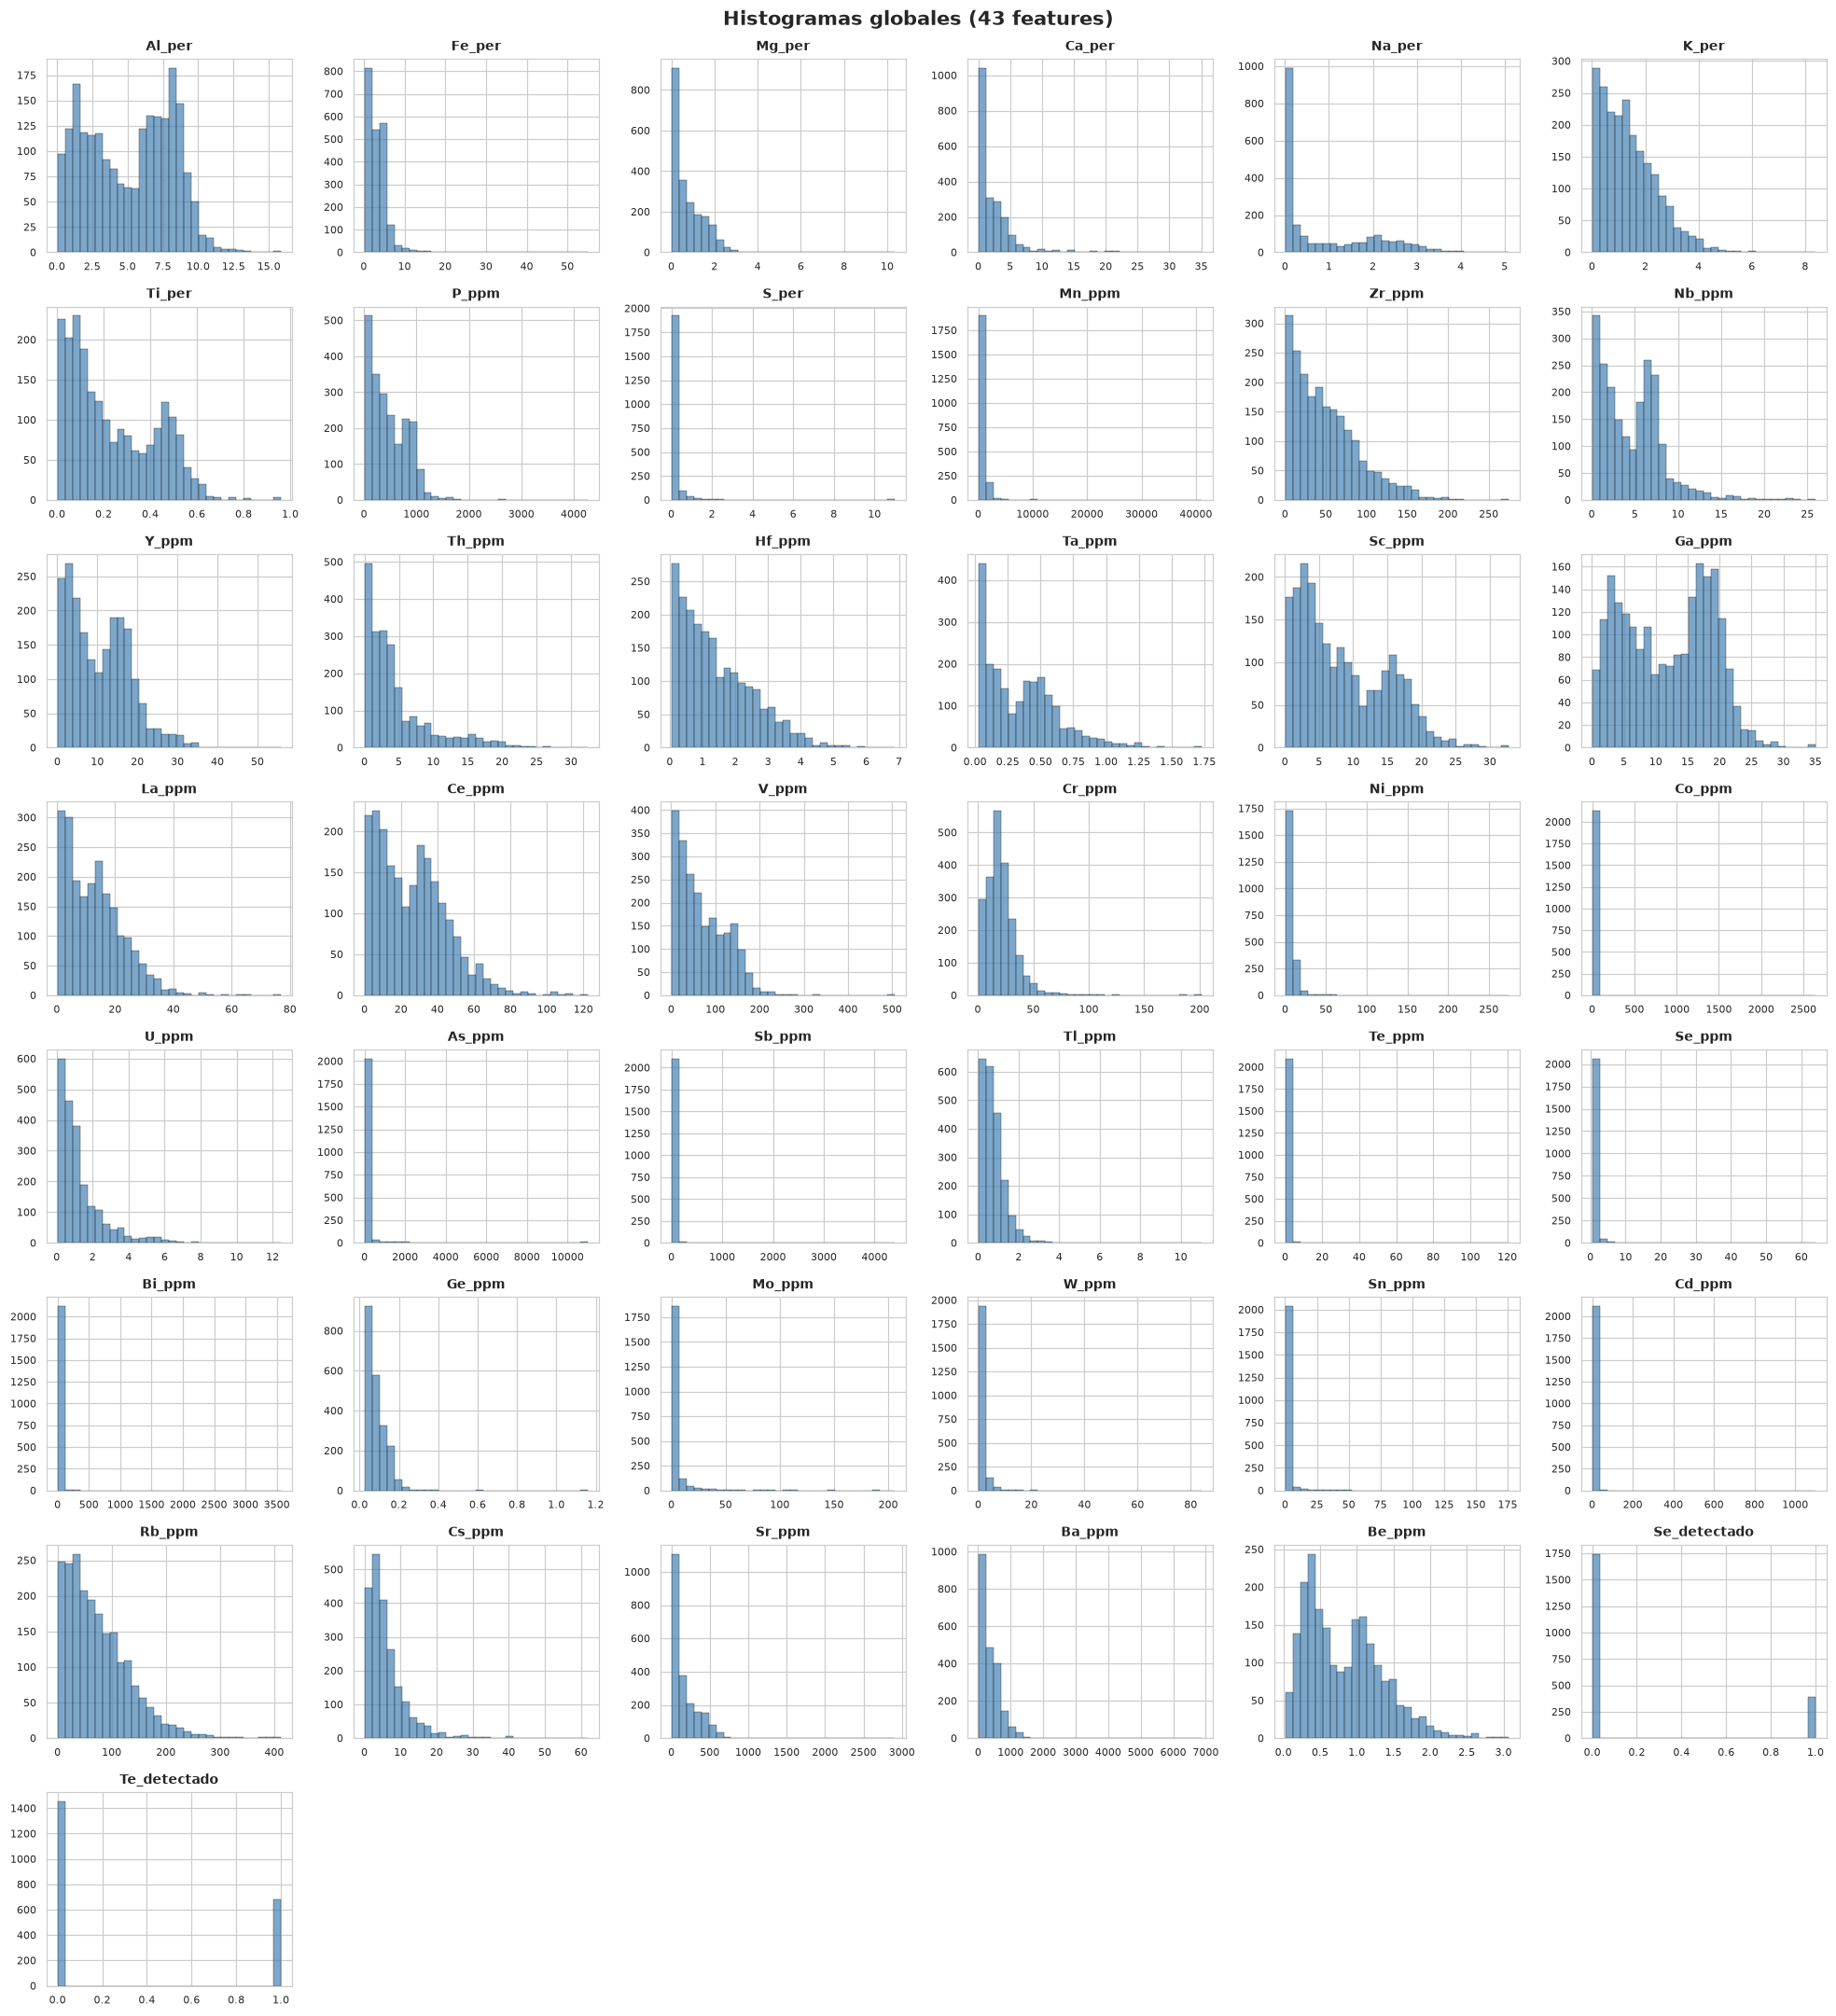

In [12]:
n_feat = len(FEATURES)
ncols = 6; nrows = int(np.ceil(n_feat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.5))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].hist(df[feat].dropna(), bins=30, color='steelblue', edgecolor='black', linewidth=.3, alpha=.7)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle(f'Histogramas globales ({len(FEATURES)} features)', fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.savefig(f'{DIR_FIG}/eda_histogramas_global.png', bbox_inches='tight'); plt.show()

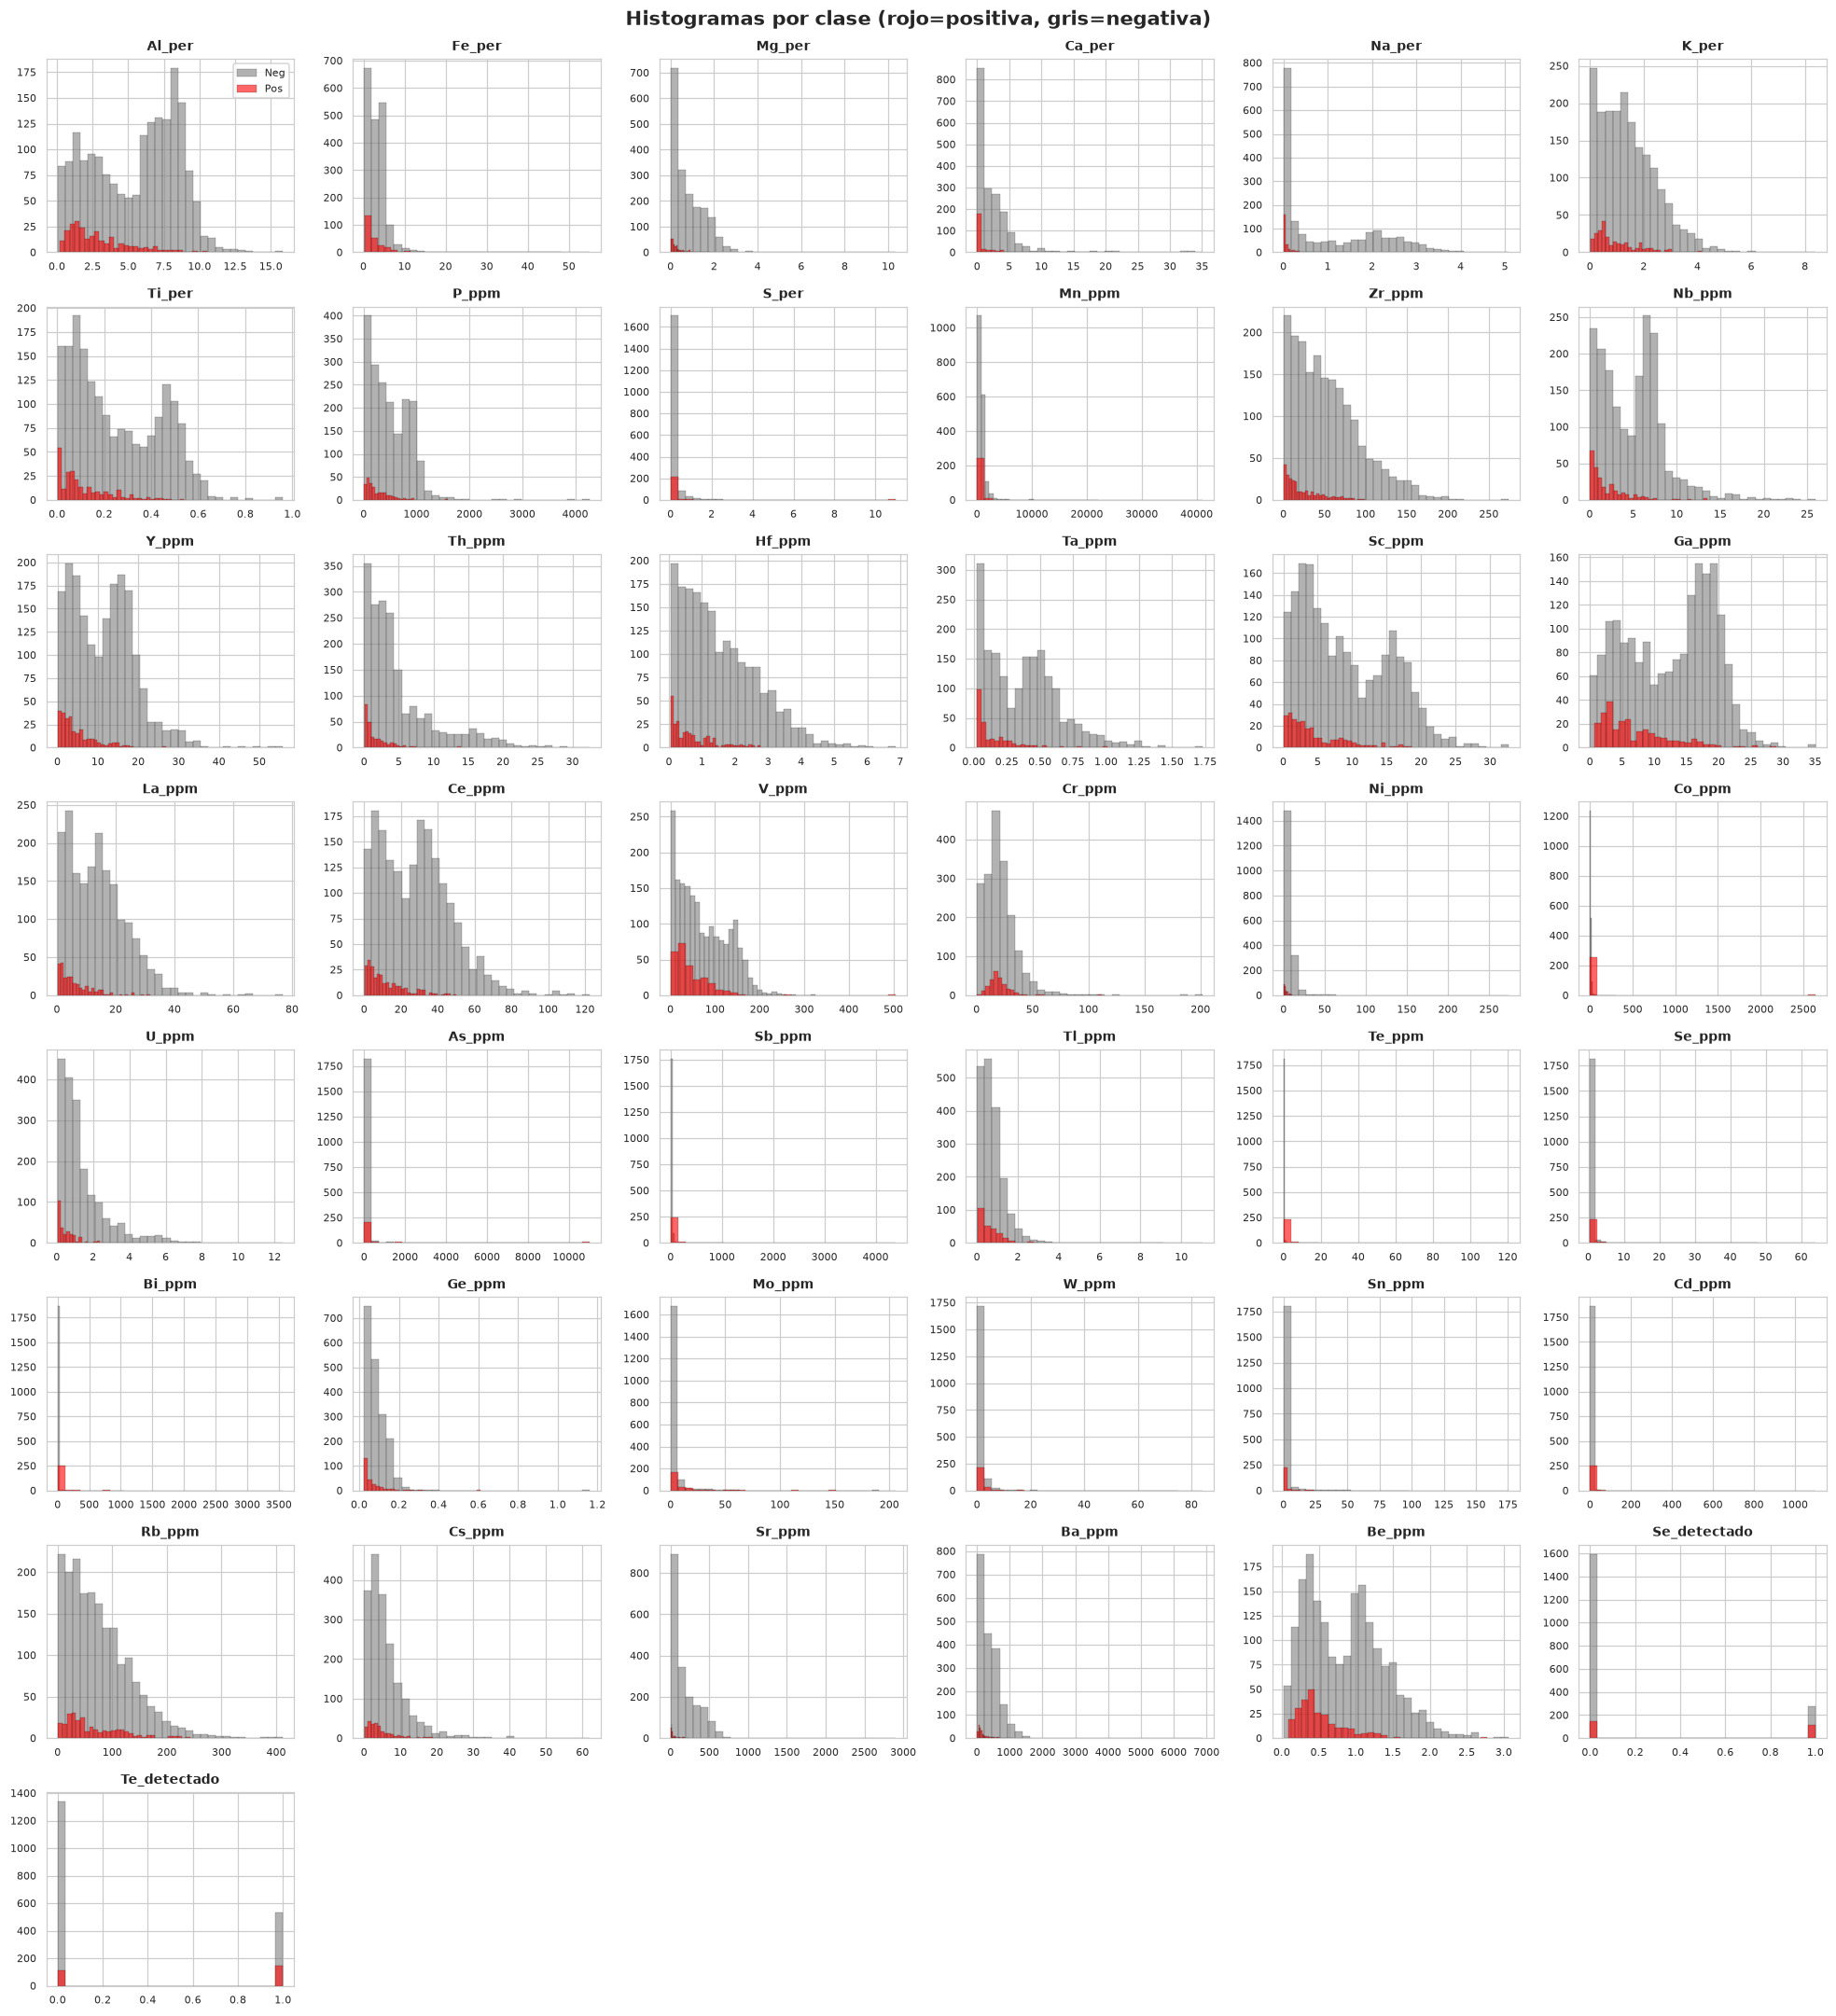

In [13]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.5))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].hist(df_neg[feat].dropna(), bins=30, color='gray', alpha=.6, label='Neg', edgecolor='black', linewidth=.2)
    axes[i].hist(df_pos[feat].dropna(), bins=30, color='red', alpha=.6, label='Pos', edgecolor='black', linewidth=.2)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
    if i == 0: axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Histogramas por clase (rojo=positiva, gris=negativa)', fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.savefig(f'{DIR_FIG}/eda_histogramas_clase.png', bbox_inches='tight'); plt.show()

### Boxplots

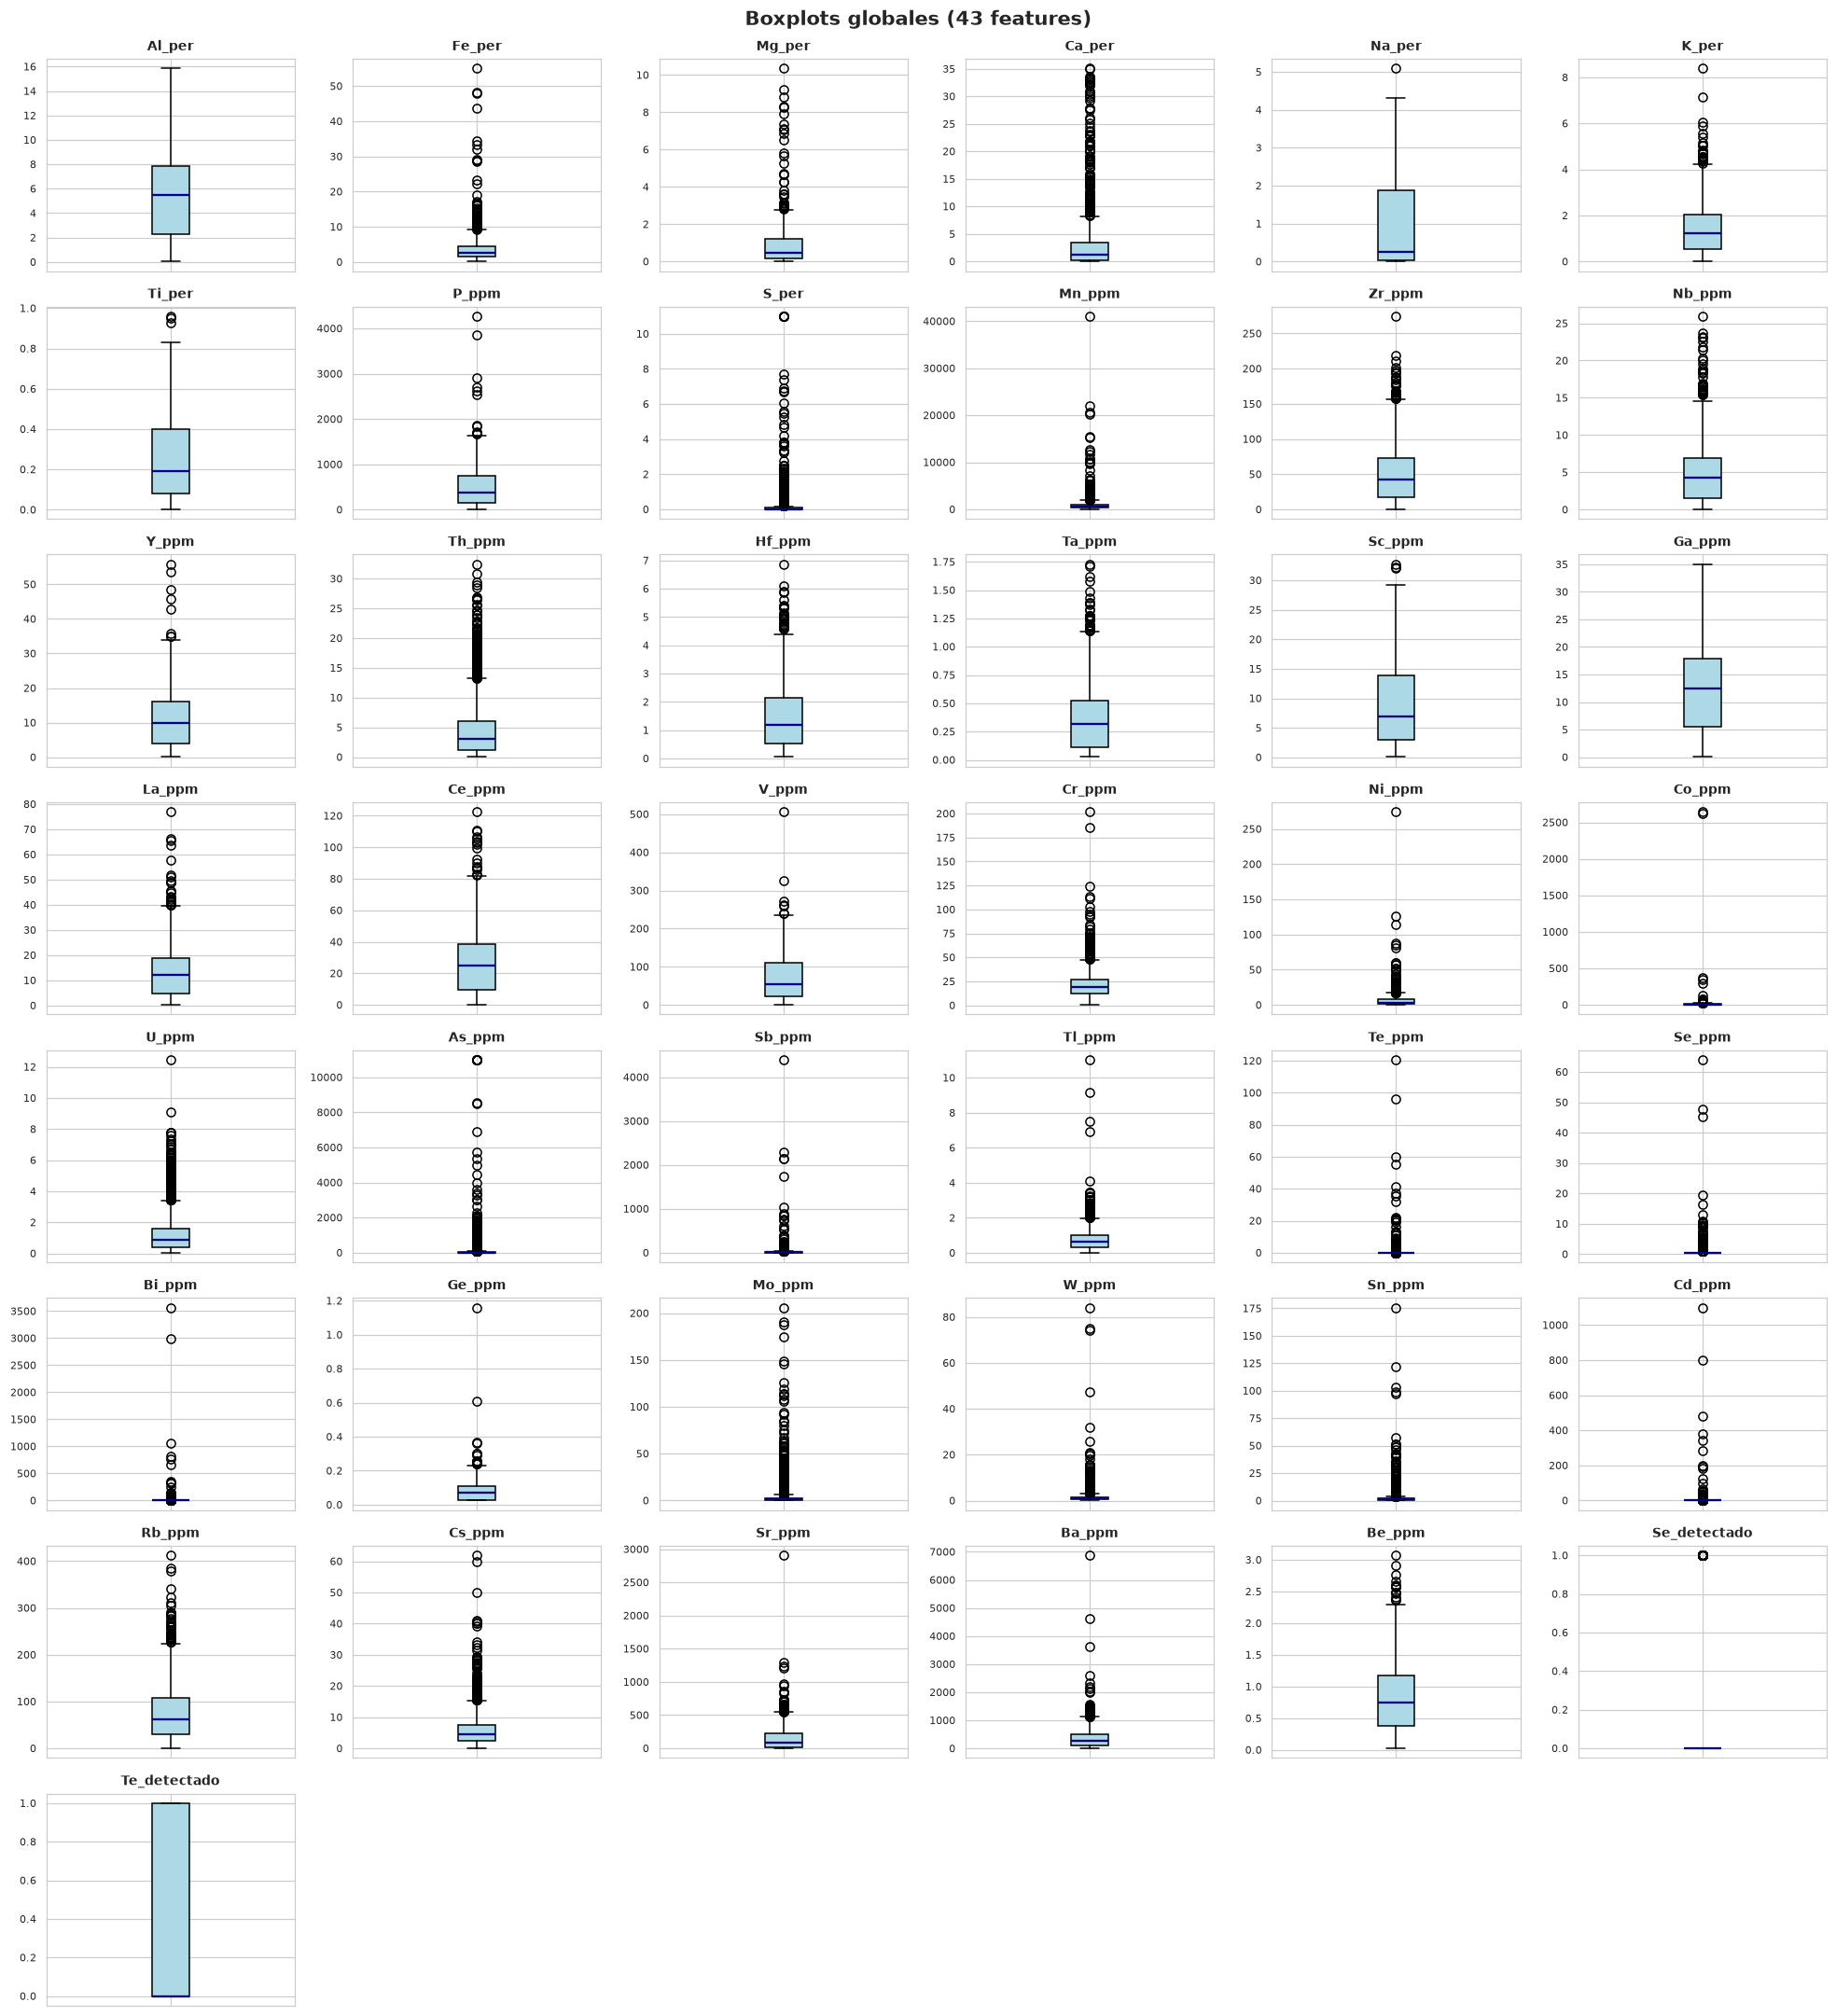

In [14]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.5))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].boxplot(df[feat].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', edgecolor='black'),
                    medianprops=dict(color='darkblue', linewidth=1.5))
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7); axes[i].set_xticklabels([''])
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle(f'Boxplots globales ({len(FEATURES)} features)', fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.savefig(f'{DIR_FIG}/eda_boxplots_global.png', bbox_inches='tight'); plt.show()

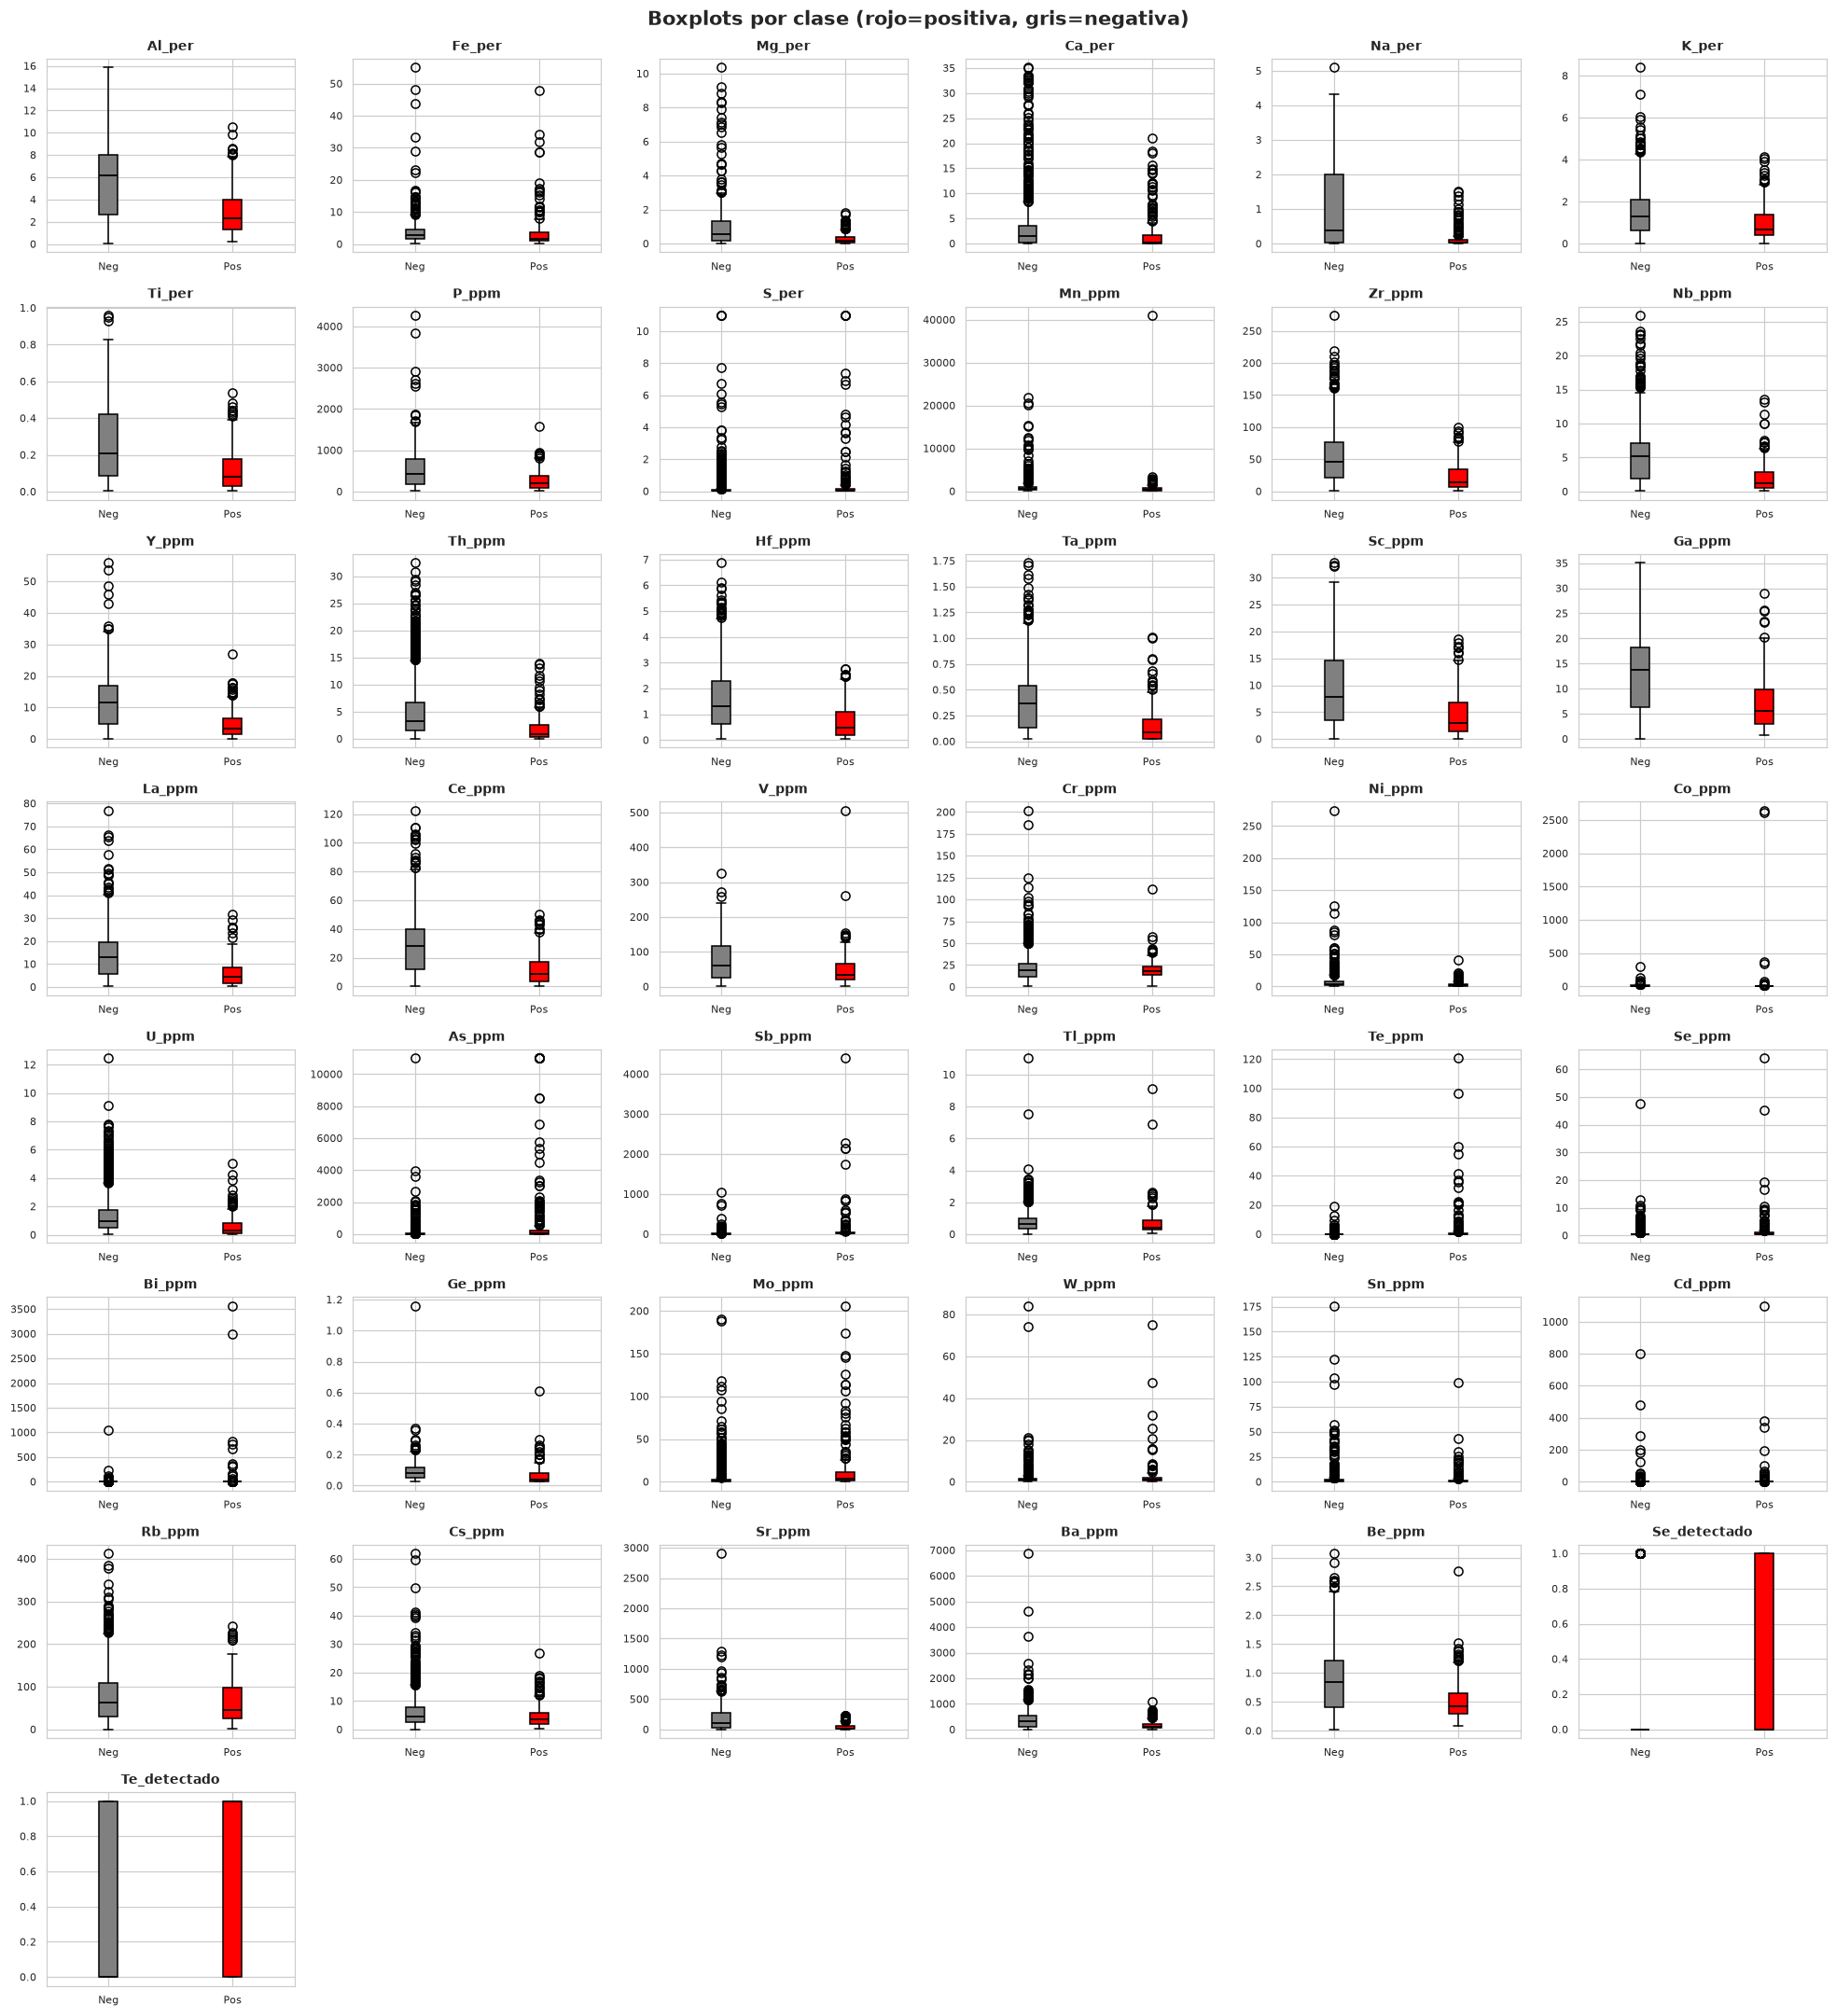

In [15]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.5))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    data = [df_neg[feat].dropna(), df_pos[feat].dropna()]
    bp = axes[i].boxplot(data, vert=True, patch_artist=True, tick_labels=['Neg', 'Pos'],
                         medianprops=dict(color='black', linewidth=1.2))
    bp['boxes'][0].set_facecolor('gray'); bp['boxes'][1].set_facecolor('red')
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Boxplots por clase (rojo=positiva, gris=negativa)', fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.savefig(f'{DIR_FIG}/eda_boxplots_clase.png', bbox_inches='tight'); plt.show()

### Matriz de correlación

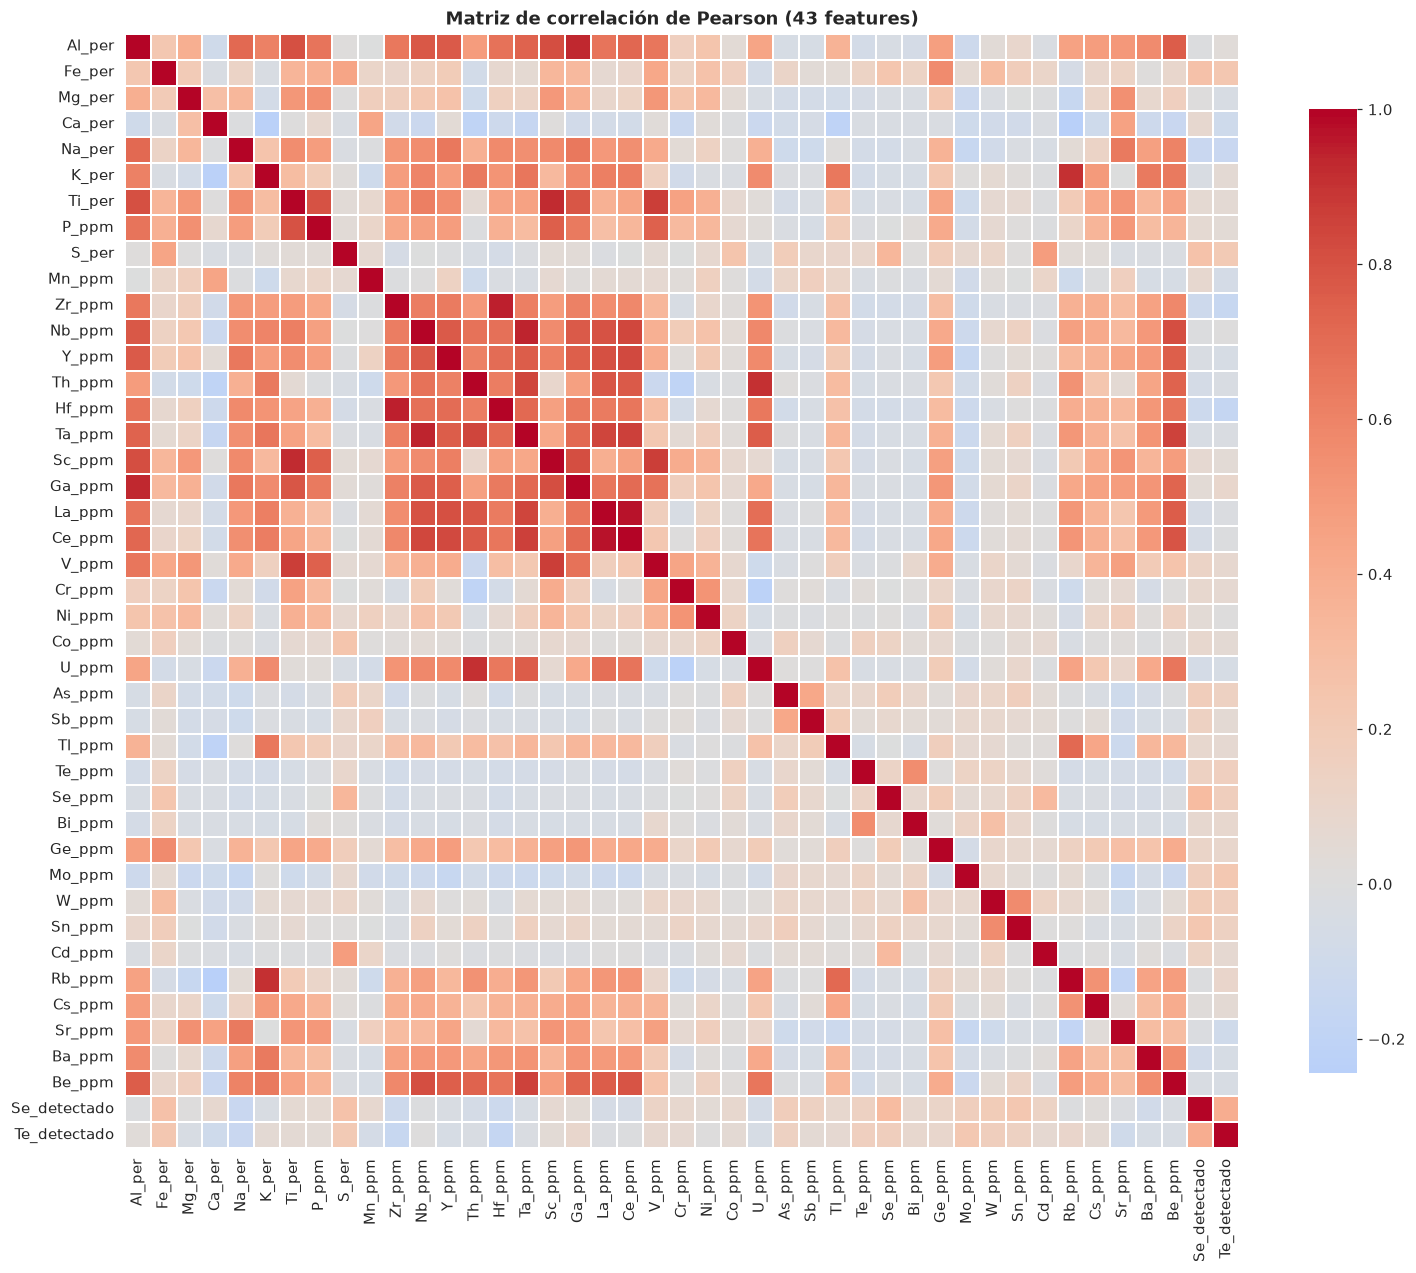

In [16]:
corr_p = df[FEATURES].corr(method='pearson')
corr_p.to_csv(f'{DIR_TAB}/eda_correlacion_pearson.csv')
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_p, cmap='coolwarm', center=0, square=True, linewidths=.3, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title(f'Matriz de correlación de Pearson ({len(FEATURES)} features)', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/eda_correlacion_pearson.png', bbox_inches='tight'); plt.show()

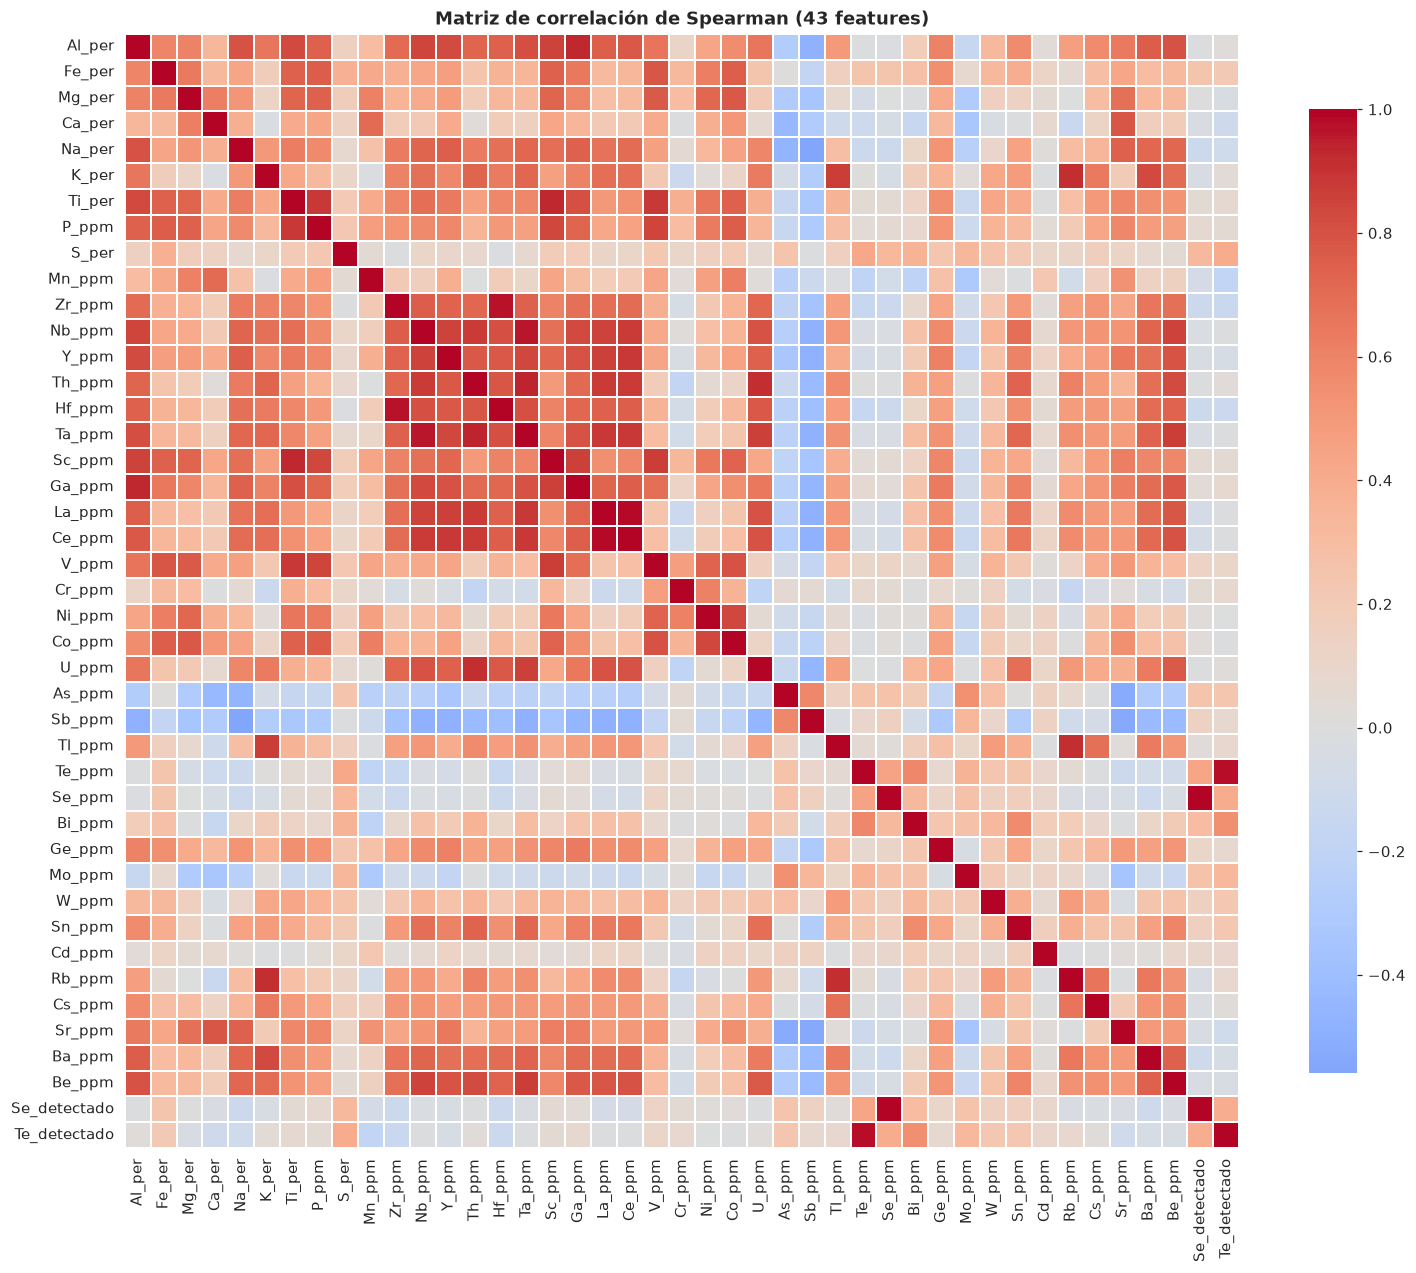

In [17]:
corr_s = df[FEATURES].corr(method='spearman')
corr_s.to_csv(f'{DIR_TAB}/eda_correlacion_spearman.csv')
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_s, cmap='coolwarm', center=0, square=True, linewidths=.3, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title(f'Matriz de correlación de Spearman ({len(FEATURES)} features)', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/eda_correlacion_spearman.png', bbox_inches='tight'); plt.show()

### Mapa de distribución espacial de clases

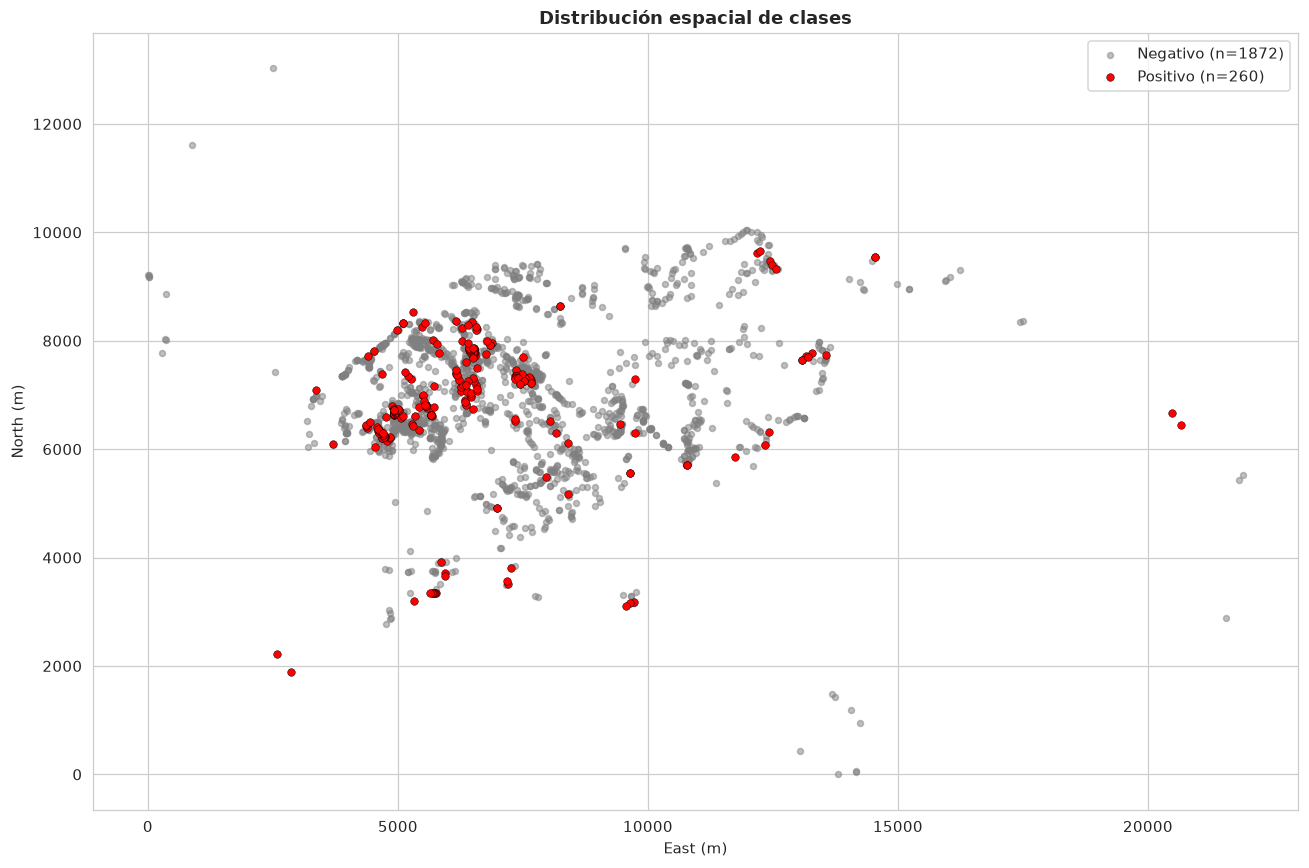

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(df[df['target_Au']==0]['East'], df[df['target_Au']==0]['North'],
           s=15, c='gray', alpha=.5, label=f'Negativo (n={n_neg})')
ax.scatter(df[df['target_Au']==1]['East'], df[df['target_Au']==1]['North'],
           s=25, c='red', edgecolor='black', linewidth=.3, label=f'Positivo (n={n_pos})')
ax.set_title('Distribución espacial de clases', fontweight='bold')
ax.set_xlabel('East (m)'); ax.set_ylabel('North (m)'); ax.legend()
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/eda_mapa_clases.png', bbox_inches='tight'); plt.show()

## Estrategia de split

**Decisión:** hold-out aleatorio estratificado 80/20 + CV 5-fold estratificada como métrica primaria.

**Justificación:**
- Dataset pequeño-mediano (~2100 muestras) → hold-out único inestable; CV reutiliza todos los datos.
- Desbalance 7:1 → estratificación obligatoria en split y folds.
- 80/20 estándar cuando el conjunto es limitado (~52 positivos en test sin restar mucho al train).

**Split aleatorio (no espacial):** el modelo busca identificar zonas ciegas **dentro** del área ya muestreada (densificación), no extrapolar a terreno nuevo. El ML explota la firma geoquímica
multivariable que se propaga entre vecinos; un split espacial estricto rompería esa señal. A continuación se **cuantifica** la autocorrelación espacial para verificar el supuesto.

In [19]:
X = df[FEATURES].copy()
y = df['target_Au'].astype(int).copy()

X_train, X_test, y_train, y_test, coords_train, coords_test = train_test_split(
    X, y, df[COORDS], test_size=0.20, stratify=y, random_state=SEED)

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

prev_tr = y_train.mean(); prev_te = y_test.mean()
print('── Verificación de la estratificación ──')
print(f'Dataset completo: {y.mean()*100:.2f}%')
print(f'Train (80%): {prev_tr*100:.2f}%  · n={len(y_train)} · pos={int(y_train.sum())}')
print(f'Test  (20%): {prev_te*100:.2f}%  · n={len(y_test)}  · pos={int(y_test.sum())}')
print(f'Diferencia: {abs(prev_tr-prev_te)*100:.3f} pp (≈0 → bien estratificado)')

# ── Persistir índices para que S1–S4 carguen el MISMO split ──
np.save(f'{DIR_DATA}/idx_train.npy', X_train.index.values)
np.save(f'{DIR_DATA}/idx_test.npy', X_test.index.values)
print(f'Índices persistidos: {DIR_DATA}/idx_train.npy, idx_test.npy')

── Verificación de la estratificación ──
Dataset completo: 12.20%
Train (80%): 12.20%  · n=1705 · pos=208
Test  (20%): 12.18%  · n=427  · pos=52
Diferencia: 0.021 pp (≈0 → bien estratificado)
Índices persistidos: outputs_sprint0/data/idx_train.npy, idx_test.npy


── Autocorrelación espacial ──
Test  → vecino de train: media=50.0  mediana=21.8
Train → vecino de train: media=49.0  mediana=19.8

Razón (mediana test/train) = 1.10
Razón ≈1 → test rodeado de train a distancia comparable → densificación intra-área
Split ALEATORIO estratificado es apropiado para el objetivo.


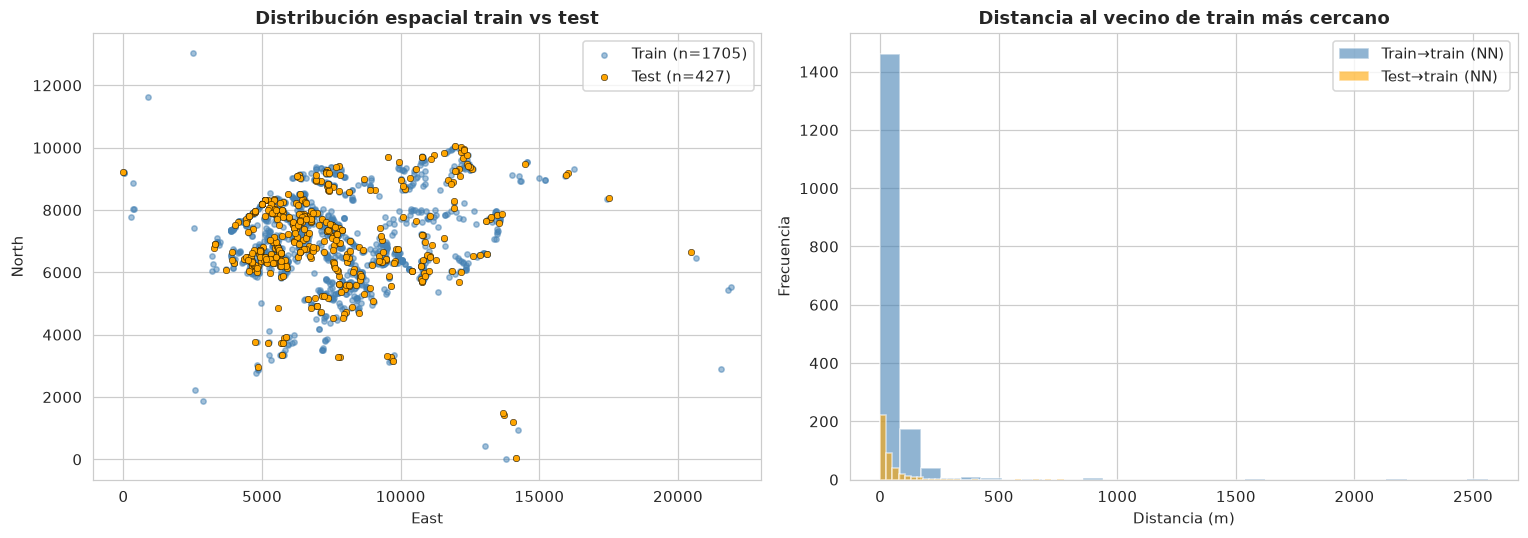

In [21]:
tree_train = cKDTree(coords_train[['East', 'North']].values)
d_test, _ = tree_train.query(coords_test[['East', 'North']].values, k=1)
d_train, _ = tree_train.query(coords_train[['East', 'North']].values, k=2)
d_train_nn = d_train[:, 1]

print('── Autocorrelación espacial ──')
print(f'Test  → vecino de train: media={d_test.mean():.1f}  mediana={np.median(d_test):.1f}')
print(f'Train → vecino de train: media={d_train_nn.mean():.1f}  mediana={np.median(d_train_nn):.1f}')
print(f'\nRazón (mediana test/train) = {np.median(d_test)/np.median(d_train_nn):.2f}')
print('Razón ≈1 → test rodeado de train a distancia comparable → densificación intra-área')
print('Split ALEATORIO estratificado es apropiado para el objetivo.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(coords_train['East'], coords_train['North'], s=12, c='steelblue', alpha=.5,
                label=f'Train (n={len(coords_train)})')
axes[0].scatter(coords_test['East'], coords_test['North'], s=18, c='orange', edgecolor='black',
                linewidth=.3, label=f'Test (n={len(coords_test)})')
axes[0].set_title('Distribución espacial train vs test', fontweight='bold')
axes[0].set_xlabel('East'); axes[0].set_ylabel('North'); axes[0].legend()
axes[1].hist(d_train_nn, bins=30, alpha=.6, color='steelblue', label='Train→train (NN)')
axes[1].hist(d_test, bins=30, alpha=.6, color='orange', label='Test→train (NN)')
axes[1].set_title('Distancia al vecino de train más cercano', fontweight='bold')
axes[1].set_xlabel('Distancia (m)'); axes[1].set_ylabel('Frecuencia'); axes[1].legend()
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/eda_autocorr_espacial.png', bbox_inches='tight'); plt.show()

## Justificación de la métrica principal

Clasificación binaria con desbalance ≈7:1 (12% positivos), clase de interés = positiva (**zonas ciegas para muestreo dirigido**).

**Estructura de costos del caso de uso:**
- **Falso negativo** (zona ciega que el modelo no marca) = oportunidad de descubrimiento perdida → **error caro**.
- **Falso positivo** (zona marcada que resulta estéril) = un muestreo dirigido sin resultado → costo acotado, normal en exploración.

Con costos asimétricos, la jerarquía de métricas es:

| Rol | Métrica | Umbral | Justificación |
|---|---|---|---|
| **Principal** | Recall (clase positiva) | ≥ 0.75 mínimo · ≥ 0.80 deseable | "De todas las zonas mineralizadas, ¿cuántas detecta?" — rango reportado por la literatura comparable: Sun et al. (2020) y Nathwani et al. (2022) 0.78–0.80 (SVM/ANN); Xu et al. (2025) 0.728 (XGBoost sobre geoquímica, referencia más directa) |
| **Secundaria** | AUC-PR | ≥ 0.75 | Robusta al desbalance y threshold-free; el modelo se usará como **ranking de priorización de muestreo** (baseline ingenuo = prevalencia ≈ 0.12) |
| **Restricción** | Precision (clase positiva) | ≥ 0.60 | Evita trivializar el Recall (marcar todo positivo) |
| **Comparabilidad** | AUC-ROC, F1, Accuracy | solo reporte | AUC-ROC es la métrica más citada del área pero optimista bajo desbalance; Accuracy engañosa ("todo negativo" = 88%) |

**Escalar de decisión: F2-Score** (F<sub>β</sub> con β=2). Todas las decisiones del pipeline (comparación de modelos, Optuna, selección de features, umbral) requieren un escalar único; el F2 pondera el Recall el **doble** que la Precision:

$$F_2 = \frac{5 \cdot Precision \cdot Recall}{4 \cdot Precision + Recall}$$

β=2 traduce matemáticamente la estructura de costos (un FN cuesta ~2× un FP) y es coherente con Recall como métrica principal y Precision como restricción (van Rijsbergen 1979). F1 y las demás métricas se **reportan** en todas las tablas para comparabilidad con la bibliografía, pero **no deciden**.

**Decisión:** F2 (clase positiva) por CV 5-fold estratificada como escalar de decisión; Recall y AUC-PR como métricas de la matriz de consistencia; Precision, F1, AUC-ROC y Accuracy complementarias.

## Baseline

Configuración por defecto/ligera con respaldo bibliográfico. Sin balanceo ni pesos de clase (Sprint 0 = baseline puro; el tratamiento del desbalance es la pregunta del Sprint 1).

| Modelo | Hiperparámetros | Ref. Teórica | Ref. Geociencias |
|---|---|---|---|
| KNN | `n_neighbors=5` | Hastie et al. (2009), Elements of Statistical Learning | Abedi et al. (2012), Comp. Geosci. — mapeo de prospectividad Au |
| Reg. Logística | `max_iter=1000`, L2 | Bishop (2006), *Pattern Recognition and ML* | Carranza (2008), Math. Geosci. — predicción de depósitos minerales |
| SVM (RBF) | `kernel='rbf'`, `gamma='scale'` | Cortes & Vapnik (1995), *Support-Vector Networks* | Zuo & Carranza (2011), Comp. Geosci. — prospectividad geoquímica |
| MLP | `hidden=(100,)`, `max_iter=500` | Goodfellow et al. (2016), *Deep Learning* | Porwal et al. (2015), Ore Geol. Rev. — mapeo predictivo mineral |
| Árbol de decisión | por defecto | Breiman et al. (1984), *CART* | Harris et al. (2015), Nat. Res. Res. — exploración geoquímica |
| Random Forest | `n_estimators=100` | Breiman (2001), *Random Forests* | Carranza & Laborte (2015), Geosci. Front. — prospectividad Au-Cu |
| ExtraTrees | `n_estimators=100` | Geurts et al. (2006), *Extremely Randomized Trees* | Rodriguez-Galiano et al. (2015), Comp. Geosci. — modelado geológico |
| HistGradientBoosting | por defecto | Ke et al. (2017), *LightGBM*, NeurIPS | Chen et al. (2019), Nat. Res. Res. — predicción de mineralización |
| XGBoost | `n_estimators=100`, `tree_method='hist'` | Chen & Guestrin (2016), *XGBoost*, KDD | Sun et al. (2020), Ore Geol. Rev. — prospectividad geoquímica Au |
| LightGBM | `n_estimators=100` | Ke et al. (2017), NeurIPS | Li et al. (2021), Minerals — clasificación de anomalías geoquímicas |
| CatBoost | `iterations=100` | Prokhorenkova et al. (2018), *CatBoost*, NeurIPS | Zuo et al. (2022), Math. Geosci. — mapeo de prospectividad con ML |

*Nota:* el SVM va **sin** `class_weight='balanced'` — todos los modelos compiten en igualdad de condiciones; cualquier tratamiento del desbalanceo se evalúa de forma controlada en el Sprint 1.

Pipeline con `StandardScaler` (necesario para KNN/LogReg/SVM/MLP, inofensivo para árboles). Decisión por **F2_CV**.

In [22]:
def crear_modelos():
    '''11 modelos baseline. Pipeline con StandardScaler, sin balanceo ni pesos de clase.'''
    return {
        'KNN': Pipeline([('sc', StandardScaler()),
                         ('clf', KNeighborsClassifier(n_neighbors=5))]),
        'Reg. Logística': Pipeline([('sc', StandardScaler()),
                                     ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
        'SVM (RBF)': Pipeline([('sc', StandardScaler()),
                                ('clf', SVC(kernel='rbf', probability=True, random_state=SEED))]),
        'MLP': Pipeline([('sc', StandardScaler()),
                         ('clf', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=SEED))]),
        'Árbol de Decisión': Pipeline([('sc', StandardScaler()),
                                        ('clf', DecisionTreeClassifier(random_state=SEED))]),
        'Random Forest': Pipeline([('sc', StandardScaler()),
                                    ('clf', RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1))]),
        'ExtraTrees': Pipeline([('sc', StandardScaler()),
                                 ('clf', ExtraTreesClassifier(n_estimators=100, random_state=SEED, n_jobs=-1))]),
        'HistGradientBoosting': Pipeline([('sc', StandardScaler()),
                                           ('clf', HistGradientBoostingClassifier(random_state=SEED))]),
        'XGBoost': Pipeline([('sc', StandardScaler()),
                             ('clf', xgb.XGBClassifier(n_estimators=100, random_state=SEED,
                                                       eval_metric='logloss', tree_method='hist', n_jobs=-1))]),
        'LightGBM': Pipeline([('sc', StandardScaler()),
                              ('clf', lgb.LGBMClassifier(n_estimators=100, random_state=SEED, verbose=-1, n_jobs=-1))]),
        'CatBoost': Pipeline([('sc', StandardScaler()),
                              ('clf', CatBoostClassifier(iterations=100, random_seed=SEED, verbose=0,
                                                         allow_writing_files=False))]),
    }

def scores_pos(modelo, Xte):
    clf = modelo.named_steps['clf'] if hasattr(modelo, 'named_steps') else modelo
    if hasattr(clf, 'predict_proba'):
        return modelo.predict_proba(Xte)[:, 1]
    return modelo.decision_function(Xte)

# ── Escalar de decisión: F2 (β=2 → Recall pesa el doble que Precision) ──
f2_scorer = make_scorer(fbeta_score, beta=2)
SCORING_CV = {'F2': f2_scorer, 'Recall': 'recall', 'Precision': 'precision',
              'F1': 'f1', 'AUC-PR': 'average_precision'}

def metricas_cv(modelo):
    '''Métricas por CV 5-fold estratificada. F2 = escalar de DECISIÓN.'''
    res = cross_validate(modelo, X_train, y_train, cv=CV5, scoring=SCORING_CV, n_jobs=-1)
    return {k: (res[f'test_{k}'].mean(), res[f'test_{k}'].std()) for k in SCORING_CV}

def metricas_holdout(yte, y_pred, y_sco):
    return {
        'F2': fbeta_score(yte, y_pred, beta=2), 'Recall': recall_score(yte, y_pred),
        'Precision': precision_score(yte, y_pred, zero_division=0), 'F1': f1_score(yte, y_pred),
        'Accuracy': accuracy_score(yte, y_pred),
        'AUC-ROC': roc_auc_score(yte, y_sco), 'AUC-PR': average_precision_score(yte, y_sco),
    }

def resaltar_maximo(s):
    estilos = [''] * len(s)
    estilos[s.index.get_loc(s.idxmax())] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('Funciones listas')

Funciones listas


In [23]:
import time
res_cv, tiempos = {}, {}
for n, m in crear_modelos().items():
    t0 = time.time()
    res_cv[n] = metricas_cv(m)
    tiempos[n] = time.time() - t0
    f2_mu, f2_sd = res_cv[n]['F2']
    rec_mu = res_cv[n]['Recall'][0]; pre_mu = res_cv[n]['Precision'][0]
    print(f'  {n}: F2_CV={f2_mu:.4f} ± {f2_sd:.4f} · Recall={rec_mu:.4f} · Precision={pre_mu:.4f} ({tiempos[n]:.1f}s)')

tabla_cv = pd.DataFrame({
    'F2_CV (media)': {n: res_cv[n]['F2'][0] for n in MODELOS},
    'F2_CV (std)': {n: res_cv[n]['F2'][1] for n in MODELOS},
    'Recall_CV': {n: res_cv[n]['Recall'][0] for n in MODELOS},
    'Precision_CV': {n: res_cv[n]['Precision'][0] for n in MODELOS},
    'F1_CV': {n: res_cv[n]['F1'][0] for n in MODELOS},
    'AUC-PR_CV': {n: res_cv[n]['AUC-PR'][0] for n in MODELOS},
    'Tiempo (s)': tiempos,
}).loc[MODELOS].round(4)
tabla_cv.to_csv(f'{DIR_TAB}/baseline_f2_cv.csv')

mejor_modelo = tabla_cv['F2_CV (media)'].idxmax()
print(coral(f'\nGANADOR por F2_CV: {mejor_modelo} '
      f'(F2_CV = {tabla_cv.loc[mejor_modelo, "F2_CV (media)"]:.4f} ± '
      f'{tabla_cv.loc[mejor_modelo, "F2_CV (std)"]:.4f})'))
tabla_cv.style.apply(resaltar_maximo, axis=0, subset=['F2_CV (media)'])\
        .format('{:.4f}', subset=['F2_CV (media)', 'F2_CV (std)', 'Recall_CV', 'Precision_CV', 'F1_CV', 'AUC-PR_CV'])\
        .format('{:.1f}', subset=['Tiempo (s)'])

  KNN: F2_CV=0.4149 ± 0.0652 · Recall=0.3895 · Precision=0.5765 (5.7s)
  Reg. Logística: F2_CV=0.4034 ± 0.0833 · Recall=0.3652 · Precision=0.7161 (0.1s)
  SVM (RBF): F2_CV=0.1883 ± 0.0478 · Recall=0.1585 · Precision=0.8305 (1.0s)
  MLP: F2_CV=0.5432 ± 0.0799 · Recall=0.5235 · Precision=0.6581 (9.8s)
  Árbol de Decisión: F2_CV=0.5112 ± 0.0314 · Recall=0.5193 · Precision=0.4884 (0.2s)
  Random Forest: F2_CV=0.3848 ± 0.0738 · Recall=0.3456 · Precision=0.7553 (2.4s)
  ExtraTrees: F2_CV=0.3881 ± 0.0285 · Recall=0.3465 · Precision=0.7808 (1.5s)
  HistGradientBoosting: F2_CV=0.5223 ± 0.0880 · Recall=0.4899 · Precision=0.7574 (2.0s)
  XGBoost: F2_CV=0.5214 ± 0.0444 · Recall=0.4901 · Precision=0.7334 (5.5s)
  LightGBM: F2_CV=0.5276 ± 0.0241 · Recall=0.4951 · Precision=0.7370 (8.0s)
  CatBoost: F2_CV=0.4851 ± 0.0689 · Recall=0.4513 · Precision=0.7607 (5.2s)

GANADOR por F2_CV: MLP (F2_CV = 0.5432 ± 0.0799)


,F2_CV (media),F2_CV (std),Recall_CV,Precision_CV,F1_CV,AUC-PR_CV,Tiempo (s)
KNN,0.4149,0.0652,0.3895,0.5765,0.4613,0.4488,5.7
Reg. Logística,0.4034,0.0833,0.3652,0.7161,0.4799,0.6027,0.1
SVM (RBF),0.1883,0.0478,0.1585,0.8305,0.2626,0.5350,1.0
MLP,0.5432,0.0799,0.5235,0.6581,0.5780,0.6304,9.8
Árbol de Decisión,0.5112,0.0314,0.5193,0.4884,0.5008,0.3118,0.2
Random Forest,0.3848,0.0738,0.3456,0.7553,0.4659,0.6678,2.4
ExtraTrees,0.3881,0.0285,0.3465,0.7808,0.4752,0.6519,1.5
HistGradientBoosting,0.5223,0.0880,0.4899,0.7574,0.5835,0.7112,2.0
XGBoost,0.5214,0.0444,0.4901,0.7334,0.5797,0.6745,5.5
LightGBM,0.5276,0.0241,0.4951,0.7370,0.5871,0.7136,8.0


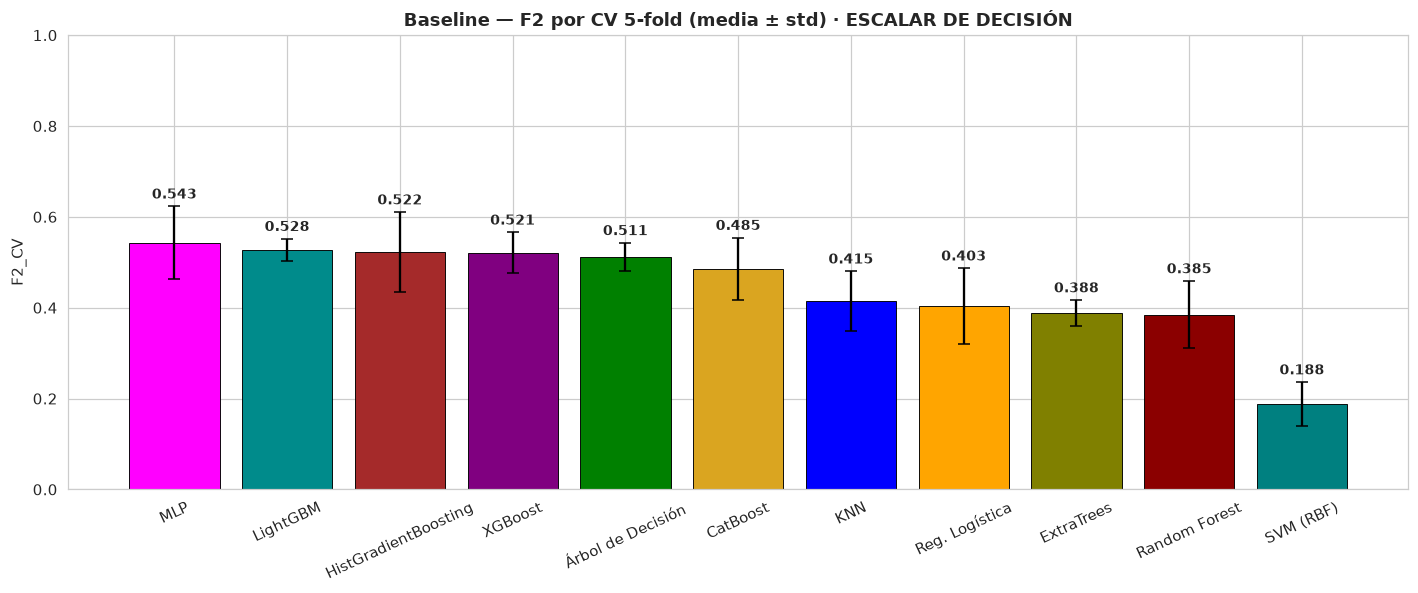

In [24]:
orden = tabla_cv['F2_CV (media)'].sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(13, 5.5))
b = ax.bar(orden, tabla_cv.loc[orden, 'F2_CV (media)'], yerr=tabla_cv.loc[orden, 'F2_CV (std)'],
           color=[MODEL_COLORS[m] for m in orden], edgecolor='black', linewidth=.6, capsize=4)
ax.set_title('Baseline — F2 por CV 5-fold (media ± std) · ESCALAR DE DECISIÓN', fontweight='bold')
ax.set_ylabel('F2_CV'); ax.set_ylim(0, 1); ax.tick_params(axis='x', rotation=25)
for r, m in zip(b, orden):
    ax.text(r.get_x()+r.get_width()/2, r.get_height()+tabla_cv.loc[m, 'F2_CV (std)']+.01,
            f'{r.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/baseline_f2_cv_barras.png', bbox_inches='tight'); plt.show()

In [25]:
modelos_guardados = {}
modelos_fit = {}
for n, m in crear_modelos().items():
    m.fit(X_train, y_train)
    modelos_fit[n] = m
    fname = 'modelo_' + (n.replace(' ', '_').replace('(', '').replace(')', '')
                          .replace('.', '').replace('á', 'a').replace('é', 'e')
                          .replace('í', 'i').replace('ó', 'o')) + '.pkl'
    ruta = f'{DIR_MODELS}/{fname}'
    joblib.dump(m, ruta)
    modelos_guardados[n] = ruta
print(f'{len(modelos_guardados)} modelos guardados en {DIR_MODELS}/')

11 modelos guardados en outputs_sprint0/models/


In [26]:
METRICAS = ['F2', 'Recall', 'Precision', 'F1', 'Accuracy', 'AUC-ROC', 'AUC-PR']
res_ho = {}
for n, m in modelos_fit.items():
    y_pred = m.predict(X_test); y_sco = scores_pos(m, X_test)
    d = metricas_holdout(y_test, y_pred, y_sco)
    d['_pred'] = y_pred; d['_score'] = y_sco
    res_ho[n] = d

tabla_ho = pd.DataFrame({m: {k: res_ho[m][k] for k in METRICAS} for m in MODELOS}).T[METRICAS].round(4)
tabla_ho.to_csv(f'{DIR_TAB}/baseline_holdout_metricas.csv')
print('Métricas en hold-out (informativas — NO deciden)')
tabla_ho.style.apply(resaltar_maximo, axis=0, subset=METRICAS).format('{:.4f}', subset=METRICAS)

Métricas en hold-out (informativas — NO deciden)


,F2,Recall,Precision,F1,Accuracy,AUC-ROC,AUC-PR
KNN,0.3138,0.2885,0.4839,0.3614,0.8759,0.8249,0.3929
Reg. Logística,0.3913,0.3462,0.8182,0.4865,0.9110,0.8885,0.6140
SVM (RBF),0.2055,0.1731,0.8182,0.2857,0.8946,0.8528,0.5435
MLP,0.5444,0.5192,0.6750,0.5870,0.9110,0.8927,0.6301
Árbol de Decisión,0.5323,0.5385,0.5091,0.5234,0.8806,0.7332,0.3303
Random Forest,0.3863,0.3462,0.7200,0.4675,0.9040,0.9262,0.6868
ExtraTrees,0.3524,0.3077,0.8421,0.4507,0.9087,0.9080,0.6738
HistGradientBoosting,0.5761,0.5385,0.8000,0.6437,0.9274,0.9370,0.7698
XGBoost,0.5165,0.4808,0.7353,0.5814,0.9157,0.9249,0.7176
LightGBM,0.5165,0.4808,0.7353,0.5814,0.9157,0.9335,0.7369


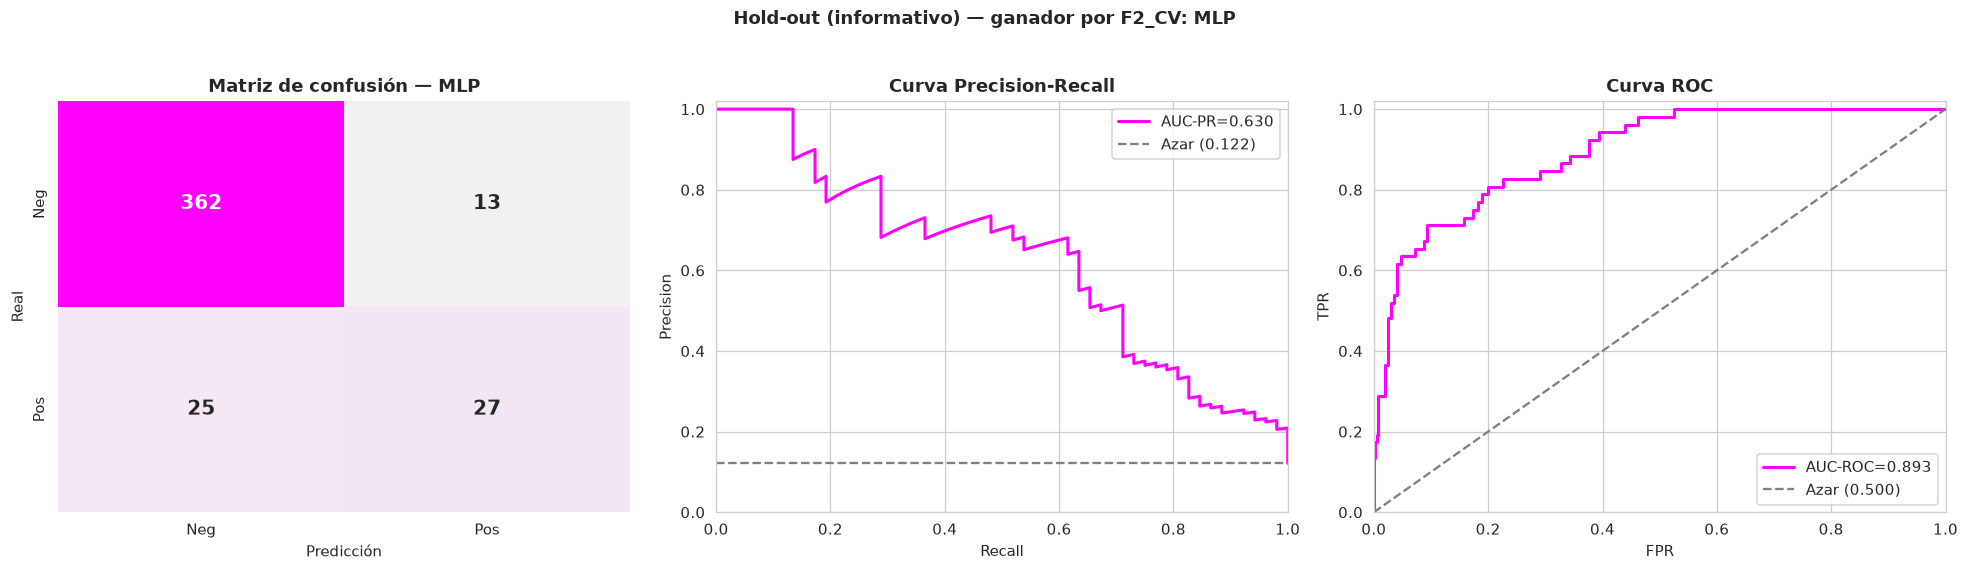

In [27]:
rm = res_ho[mejor_modelo]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, rm['_pred'])
sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=axes[0],
            cmap=sns.light_palette(MODEL_COLORS[mejor_modelo], as_cmap=True),
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[0].set_title(f'Matriz de confusión — {mejor_modelo}', fontweight='bold')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

p, r, _ = precision_recall_curve(y_test, rm['_score'])
axes[1].plot(r, p, color=MODEL_COLORS[mejor_modelo], lw=2, label=f'AUC-PR={rm["AUC-PR"]:.3f}')
axes[1].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curva Precision-Recall', fontweight='bold'); axes[1].legend()

fpr, tpr, _ = roc_curve(y_test, rm['_score'])
axes[2].plot(fpr, tpr, color=MODEL_COLORS[mejor_modelo], lw=2, label=f'AUC-ROC={rm["AUC-ROC"]:.3f}')
axes[2].plot([0, 1], [0, 1], '--', color='gray', label='Azar (0.500)')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1.02)
axes[2].set_title('Curva ROC', fontweight='bold'); axes[2].legend(loc='lower right')
plt.suptitle(f'Hold-out (informativo) — ganador por F2_CV: {mejor_modelo}', fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/baseline_ganador_curvas.png', bbox_inches='tight'); plt.show()

## Resumen

In [28]:
f2_cv_final = round(float(tabla_cv.loc[mejor_modelo, 'F2_CV (media)']), 4)
f2_cv_std_final = round(float(tabla_cv.loc[mejor_modelo, 'F2_CV (std)']), 4)

resumen0 = {
    'sprint': 0,
    'nombre': 'Baseline + ingesta/preprocesamiento + EDA',
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'dataset': {
        'n_muestras': int(df.shape[0]), 'n_features': len(FEATURES),
        'prevalencia_pos': round(prevalencia, 4), 'razon_desbalance': round(razon_desb, 2),
        'umbral_target_Au_ppm': UMBRAL_AU, 'ruta_data_procesada': RUTA_PROC,
    },
    'exclusiones': {
        'economicos': ECONOMICOS, 'censura_alta': CENSURA_ALTA,
        'indicadores_creados': INDICADORES,
        'nota': 'Au_ppm solo target; económicos excluidos por objetivo de tesis (zonas ciegas)',
    },
    'grupos_geoquimicos': {g: cols for g, cols in GRUPOS.items()},
    'split': {'estrategia': 'aleatorio estratificado', 'test_size': 0.20, 'seed': SEED,
              'prevalencia_train': round(float(prev_tr), 4), 'prevalencia_test': round(float(prev_te), 4)},
    'protocolo_cv': {'tipo': 'StratifiedKFold', 'n_splits': 5, 'shuffle': True, 'seed': SEED},
    'metrica_decision': 'f2',
    'metrica_principal': 'recall',
    'metricas_objetivo': {'recall_min': 0.75, 'recall_deseable': 0.80, 'auc_pr_min': 0.75, 'precision_min': 0.60},
    'metricas_complementarias': ['Precision', 'F1', 'AUC-PR', 'AUC-ROC', 'Accuracy'],
    'balanceo': None,
    'mejor_modelo': mejor_modelo,
    'f2_cv_media': f2_cv_final,
    'f2_cv_std': f2_cv_std_final,
    'f2_final': f2_cv_final,
    'recall_cv_ganador': round(float(tabla_cv.loc[mejor_modelo, 'Recall_CV']), 4),
    'precision_cv_ganador': round(float(tabla_cv.loc[mejor_modelo, 'Precision_CV']), 4),
    'metricas_holdout_informativo': {m: round(float(res_ho[mejor_modelo][m]), 4) for m in METRICAS},
    'f2_cv_por_modelo': {m: round(float(res_cv[m]['F2'][0]), 4) for m in MODELOS},
    'f2_std_por_modelo': {m: round(float(res_cv[m]['F2'][1]), 4) for m in MODELOS},
    'recall_cv_por_modelo': {m: round(float(res_cv[m]['Recall'][0]), 4) for m in MODELOS},
    'precision_cv_por_modelo': {m: round(float(res_cv[m]['Precision'][0]), 4) for m in MODELOS},
    'f1_cv_por_modelo': {m: round(float(res_cv[m]['F1'][0]), 4) for m in MODELOS},
    'modelos_guardados': modelos_guardados,
    'versiones_librerias': versiones,
    'indices': {'idx_train': f'{DIR_DATA}/idx_train.npy', 'idx_test': f'{DIR_DATA}/idx_test.npy'},
    'features': FEATURES,
    'rutas': {'data': DIR_DATA, 'models': DIR_MODELS, 'figures': DIR_FIG, 'tables': DIR_TAB},
}
with open(f'{OUT}/resumen_sprint0.json', 'w') as f:
    json.dump(resumen0, f, indent=2, ensure_ascii=False)

print('════════════════════ RESUMEN SPRINT 0 ════════════════════')
print(f'Dataset: {df.shape[0]} muestras · {len(FEATURES)} features · IR={razon_desb:.1f}:1 · prev={prevalencia*100:.2f}%')
print(f'Excluidos: {ECONOMICOS + CENSURA_ALTA} · Indicadores: {INDICADORES}')
print(f'Split  : aleatorio estratificado 80/20 (SEED={SEED}) — hold-out solo informativo')
print(f'Métricas: decisión=F2 · principal=Recall (≥0.75) · secundaria=AUC-PR (≥0.75) · restricción=Precision (≥0.60)')
print('\nRanking baseline por F2_CV:')
rank = tabla_cv['F2_CV (media)'].sort_values(ascending=False)
for i, (mod, f2v) in enumerate(rank.items(), 1):
    marca = ' ← GANADOR' if mod == mejor_modelo else ''
    print(f'  {i:2d}. {mod:22s} F2_CV = {f2v:.4f} ± {tabla_cv.loc[mod, "F2_CV (std)"]:.4f} · '
          f'Recall = {tabla_cv.loc[mod, "Recall_CV"]:.4f}{marca}')
print(coral(f'\nMejor baseline: {mejor_modelo}'))
print(coral(f'   F2_CV       = {f2_cv_final:.4f} ± {f2_cv_std_final:.4f}   (decisión)'))
print(f'   Recall_CV   = {tabla_cv.loc[mejor_modelo, "Recall_CV"]:.4f}   (principal — objetivo ≥ 0.75)')
print(f'   F2 hold-out = {res_ho[mejor_modelo]["F2"]:.4f}   (informativo)')
print(f'\n{len(modelos_guardados)} modelos persistidos en {DIR_MODELS}/')
print('Resumen unificado: outputs_sprint0/resumen_sprint0.json')
print('\nSiguiente (Sprint 1): balanceo (oversamplers + class_weight/scale_pos_weight) DENTRO de cada fold + PCA por bloques geoquímicos, decidiendo por F2_CV.')

════════════════════ RESUMEN SPRINT 0 ════════════════════
Dataset: 2132 muestras · 43 features · IR=7.2:1 · prev=12.20%
Excluidos: ['Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm', 'Re_ppm'] · Indicadores: ['Se_detectado', 'Te_detectado']
Split  : aleatorio estratificado 80/20 (SEED=42) — hold-out solo informativo
Métricas: decisión=F2 · principal=Recall (≥0.75) · secundaria=AUC-PR (≥0.75) · restricción=Precision (≥0.60)

Ranking baseline por F2_CV:
   1. MLP                    F2_CV = 0.5432 ± 0.0799 · Recall = 0.5235 ← GANADOR
   2. LightGBM               F2_CV = 0.5276 ± 0.0241 · Recall = 0.4951
   3. HistGradientBoosting   F2_CV = 0.5223 ± 0.0880 · Recall = 0.4899
   4. XGBoost                F2_CV = 0.5214 ± 0.0444 · Recall = 0.4901
   5. Árbol de Decisión      F2_CV = 0.5112 ± 0.0314 · Recall = 0.5193
   6. CatBoost               F2_CV = 0.4851 ± 0.0689 · Recall = 0.4513
   7. KNN                    F2_CV = 0.4149 ± 0.0652 · Recall = 0.3895
   8. Reg. Logística         F2_CV = 0.4034 ± 0